In [73]:
import pandas as pd
from datetime import datetime, timedelta

# Load the Excel file as a dataframe
file_path = r'Z:\HTOC\Data_Analytics\Data\Threat Assessment Scores\Threat_Assessment_Scores.xlsx'
df = pd.read_excel(file_path)

# Display basic information about the dataframe before filtering
print("=" * 60)
print("DATA LOADING AND FILTERING")
print("=" * 60)
print(f"\nOriginal Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Filter for indicators observed in the last 30 days
print(f"\n{'='*60}")
print("FILTERING: Indicators Last Observed in Last 30 Days")
print("=" * 60)

# Convert 'Last Observed' to datetime if not already
df['Last Observed'] = pd.to_datetime(df['Last Observed'], errors='coerce')

# Calculate days since last observed
today = pd.Timestamp.now()
df['Days_Since_Observed'] = (today - df['Last Observed']).dt.days

# Filter for last 30 days
df_original = df.copy()  # Keep original for reference
df = df[df['Days_Since_Observed'] <= 30].copy()

print(f"\nFilter Applied: Last Observed ≤ 30 days ago")
print(f"Original Indicators: {len(df_original):,}")
print(f"Filtered Indicators (Last 30 Days): {len(df):,}")
print(f"Percentage Retained: {len(df)/len(df_original)*100:.2f}%")

# Display basic information about the filtered dataframe
print(f"\n{'='*60}")
print("FILTERED DATASET INFORMATION")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nDate Range:")
if len(df) > 0:
    print(f"  Most Recent: {df['Last Observed'].max().strftime('%Y-%m-%d')}")
    print(f"  Oldest (in 30-day window): {df['Last Observed'].min().strftime('%Y-%m-%d')}")
    print(f"  Days Since Observed Range: {df['Days_Since_Observed'].min():.0f} to {df['Days_Since_Observed'].max():.0f} days")
else:
    print("  No indicators found in the last 30 days")

print(f"\nFirst few rows of filtered data:")
df.head()


DATA LOADING AND FILTERING

Original Dataset Shape: (1442, 13)
Columns: ['Indicator', 'Last Observed', 'Indicator Type', 'VirusTotal Malicious Score', 'Observation Yearly Count', 'ThreatConnect Rating', 'Observation Penalty Multiplier', 'Botnet Flag', 'False Positives', 'Partners', 'Threat Score', 'Severity', 'Score Explanation']

FILTERING: Indicators Last Observed in Last 30 Days

Filter Applied: Last Observed ≤ 30 days ago
Original Indicators: 1,442
Filtered Indicators (Last 30 Days): 1,441
Percentage Retained: 99.93%

FILTERED DATASET INFORMATION

Shape: (1441, 14)

Date Range:
  Most Recent: 2025-11-13
  Oldest (in 30-day window): 2025-10-14
  Days Since Observed Range: 0 to 30 days

First few rows of filtered data:


,Indicator,Last Observed,Indicator Type,VirusTotal Malicious Score,Observation Yearly Count,ThreatConnect Rating,Observation Penalty Multiplier,Botnet Flag,False Positives,Partners,Threat Score,Severity,Score Explanation,Days_Since_Observed
0,101.71.130.99,2025-11-13,Address,10,29.0,3,0.998411,0,0,"DHA, OS, FDA, CMS, NIH, HHS",427,medium,Severity: medium. Top drivers: VT malicious (l...,0.0
1,101.89.174.236,2025-11-12,Address,9,176.0,3,0.990356,0,0,"DHA, OS, FDA, CMS, HRSA, NIH, IHS, HHS",374,medium,Severity: medium. Top drivers: VT malicious (l...,1.0
2,102.129.153.43,2025-10-15,Address,2,16.0,3,0.999123,0,0,"FDA, CMS, VA, NIH, IHS, HHS, CDC",161,low,Severity: low. Top drivers: VT malicious (log-...,29.0
3,102.164.252.150,2025-10-29,Address,1,4.0,1,0.999781,1,0,"CMS, VA, NIH",199,low,Severity: low. Top drivers: TOR activity; TC c...,15.0
4,102.209.18.96,2025-10-24,Address,1,9.0,1,0.999507,1,0,"FDA, VA",199,low,Severity: low. Top drivers: TOR activity; TC c...,20.0


THREAT SCORE DISTRIBUTION ANALYSIS

1. Summary Statistics:
------------------------------------------------------------
count    1441.000000
mean      268.929910
std       132.756319
min         9.000000
25%       199.000000
50%       199.000000
75%       373.000000
max       760.000000
Name: Threat Score, dtype: float64

2. Additional Statistics:
------------------------------------------------------------
Total Indicators: 1441
Mean Threat Score: 268.93
Median Threat Score: 199.00
Standard Deviation: 132.76
Min Threat Score: 9.00
Max Threat Score: 760.00
Range: 751.00

3. Percentiles:
------------------------------------------------------------
10th percentile: 152.00
25th percentile: 199.00
50th percentile: 199.00
75th percentile: 373.00
90th percentile: 412.00
95th percentile: 499.00
99th percentile: 720.80


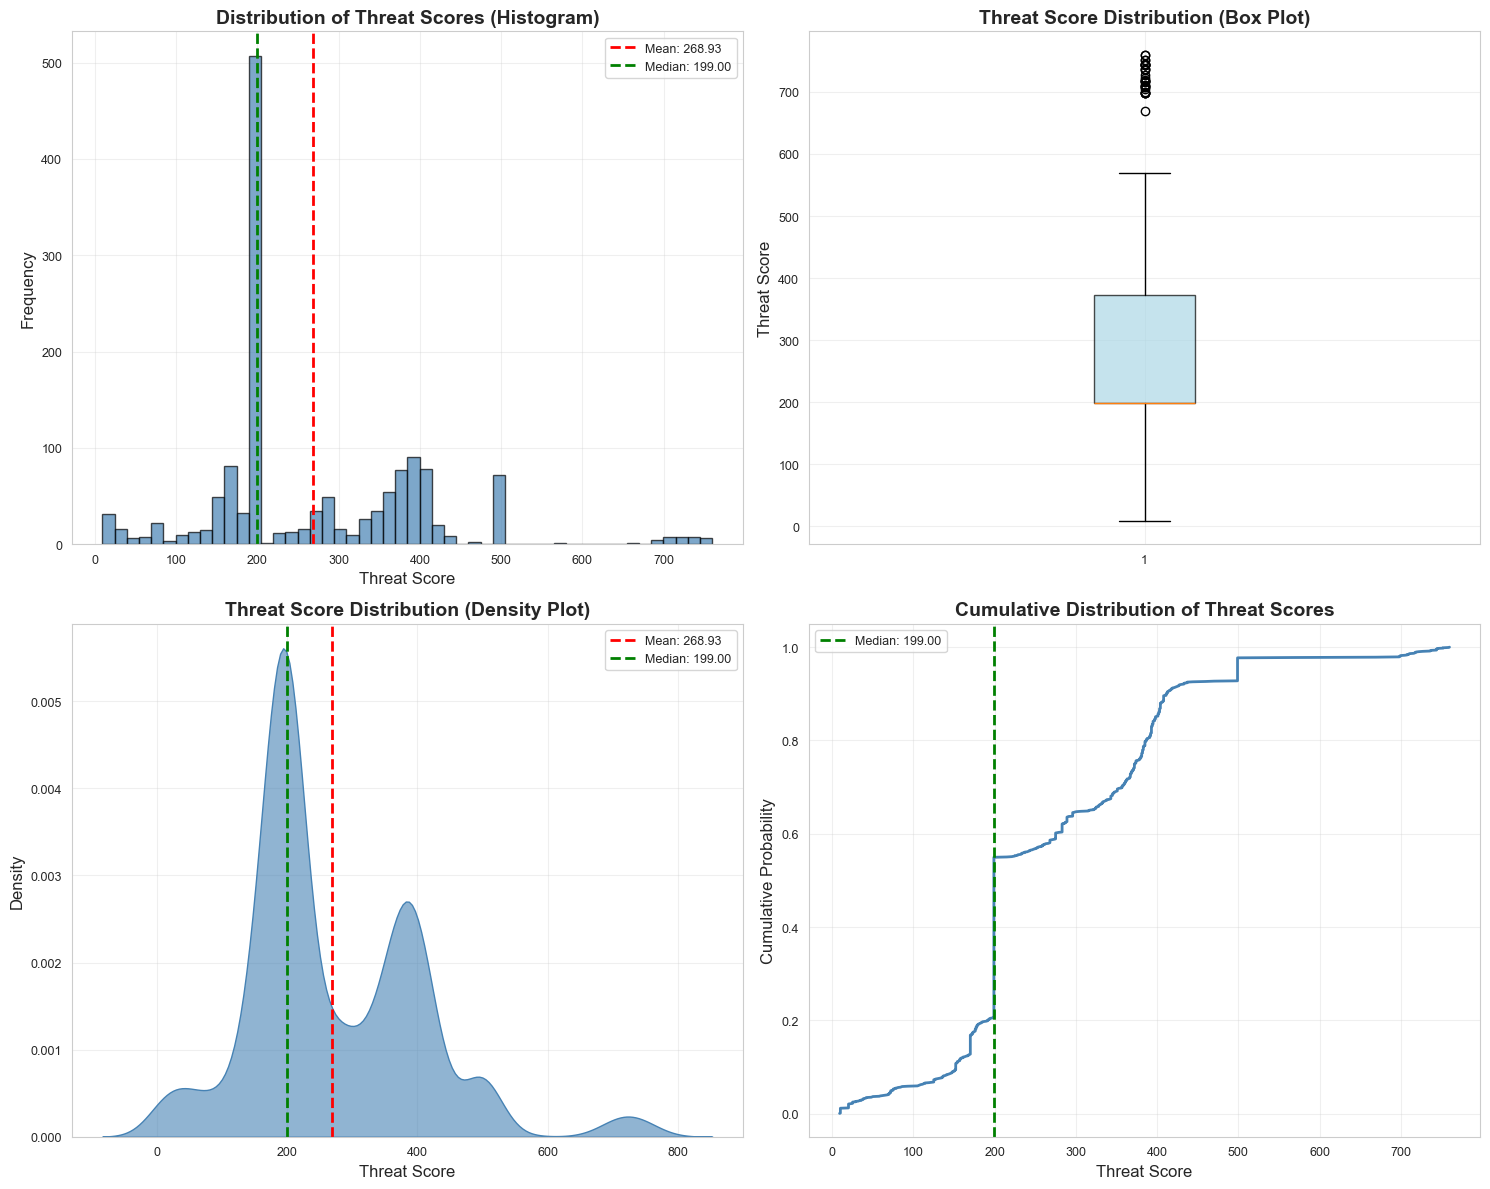


4. Score Range Breakdown:
------------------------------------------------------------
0-25: 36 indicators (2.50%)
25-50: 17 indicators (1.18%)
50-75: 23 indicators (1.60%)
75-100: 9 indicators (0.62%)


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Distribution of Threat Scores
print("=" * 60)
print("THREAT SCORE DISTRIBUTION ANALYSIS")
print("=" * 60)

# Summary Statistics
print("\n1. Summary Statistics:")
print("-" * 60)
print(df['Threat Score'].describe())

# Additional statistics
print(f"\n2. Additional Statistics:")
print("-" * 60)
print(f"Total Indicators: {len(df)}")
print(f"Mean Threat Score: {df['Threat Score'].mean():.2f}")
print(f"Median Threat Score: {df['Threat Score'].median():.2f}")
print(f"Standard Deviation: {df['Threat Score'].std():.2f}")
print(f"Min Threat Score: {df['Threat Score'].min():.2f}")
print(f"Max Threat Score: {df['Threat Score'].max():.2f}")
print(f"Range: {df['Threat Score'].max() - df['Threat Score'].min():.2f}")

# Percentiles
print(f"\n3. Percentiles:")
print("-" * 60)
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(df['Threat Score'], p):.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram
axes[0, 0].hist(df['Threat Score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['Threat Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Threat Score"].mean():.2f}')
axes[0, 0].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[0, 0].set_xlabel('Threat Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Threat Scores (Histogram)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box Plot
axes[0, 1].boxplot(df['Threat Score'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 1].set_ylabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Threat Score Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Density Plot (KDE)
sns.kdeplot(data=df, x='Threat Score', ax=axes[1, 0], fill=True, color='steelblue', alpha=0.6)
axes[1, 0].axvline(df['Threat Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Threat Score"].mean():.2f}')
axes[1, 0].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[1, 0].set_xlabel('Threat Score', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('Threat Score Distribution (Density Plot)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative Distribution
sorted_scores = np.sort(df['Threat Score'])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1, 1].plot(sorted_scores, cumulative, linewidth=2, color='steelblue')
axes[1, 1].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[1, 1].set_xlabel('Threat Score', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution of Threat Scores', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Score ranges breakdown
print(f"\n4. Score Range Breakdown:")
print("-" * 60)
bins = [0, 25, 50, 75, 100]
labels = ['0-25', '25-50', '50-75', '75-100']
df['Score_Range'] = pd.cut(df['Threat Score'], bins=bins, labels=labels, include_lowest=True)
score_distribution = df['Score_Range'].value_counts().sort_index()
for range_val, count in score_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"{range_val}: {count} indicators ({percentage:.2f}%)")


THREAT SCORE DISTRIBUTION BY PARTNERS

1. Data Overview:
------------------------------------------------------------
Total indicators: 1441
Indicators with Partners: 1412
Indicators without Partners: 29

2. Sample Partner Values:
------------------------------------------------------------
1. DHA, OS, FDA, CMS, NIH, HHS
2. DHA, OS, FDA, CMS, HRSA, NIH, IHS, HHS
3. FDA, CMS, VA, NIH, IHS, HHS, CDC
4. CMS, VA, NIH
5. FDA, VA
6. DHA, FDA
7. DHA, OS, CMS, VA, NIH
8. DHA, VA
9. DHA, VA
10. DHA, FDA, VA, HRSA, HHS

3. Partner Statistics:
------------------------------------------------------------
            Count    Mean  Median     Std  Min  Max
Partners                                           
VA           1128  283.24   228.0  127.08    9  759
CMS           998  300.25   283.0  137.50    9  760
OS            975  310.65   290.0  131.26    9  760
DHA           960  276.59   248.5  105.76    9  718
FDA           934  309.37   289.0  133.20    9  760
HHS           918  303.44   288.5  1

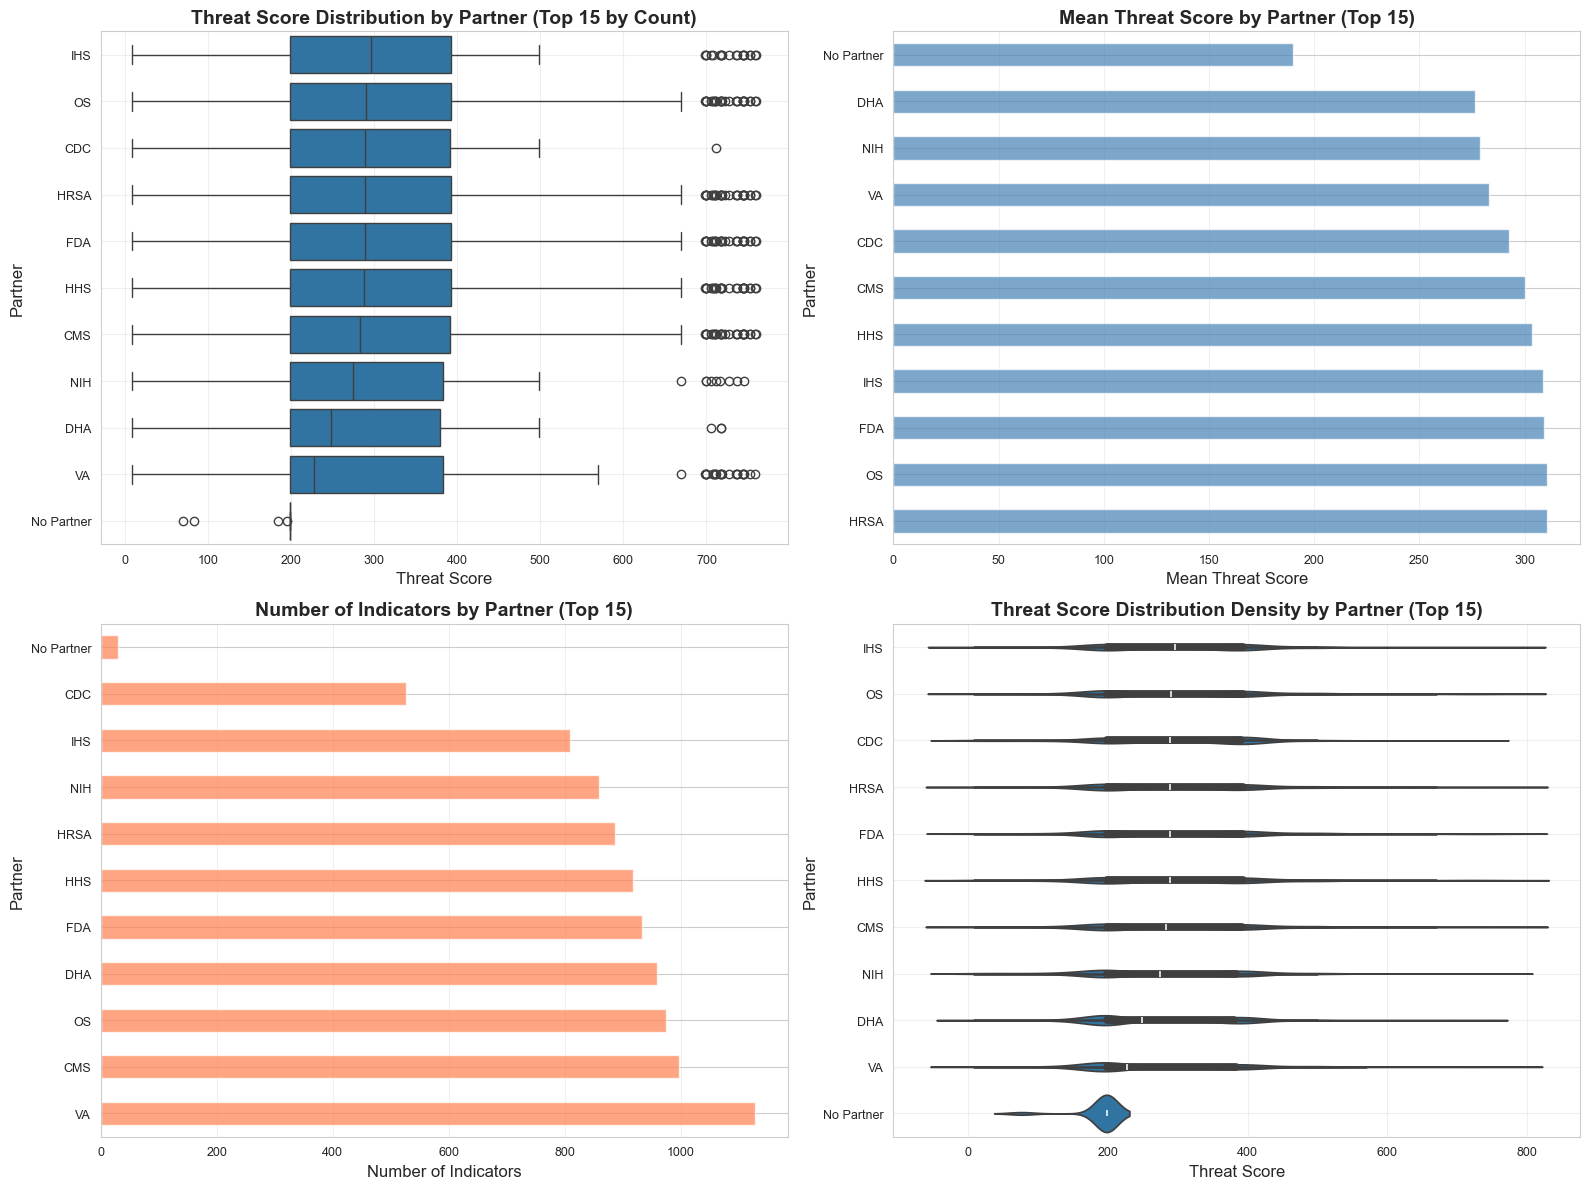


4. Detailed Breakdown by Partner:
------------------------------------------------------------

VA:
  Count: 1128
  Mean: 283.24
  Median: 228.00
  Std Dev: 127.08
  Range: 9.00 - 759.00

CMS:
  Count: 998
  Mean: 300.25
  Median: 283.00
  Std Dev: 137.50
  Range: 9.00 - 760.00

OS:
  Count: 975
  Mean: 310.65
  Median: 290.00
  Std Dev: 131.26
  Range: 9.00 - 760.00

DHA:
  Count: 960
  Mean: 276.59
  Median: 248.50
  Std Dev: 105.76
  Range: 9.00 - 718.00

FDA:
  Count: 934
  Mean: 309.37
  Median: 289.00
  Std Dev: 133.20
  Range: 9.00 - 760.00

HHS:
  Count: 918
  Mean: 303.44
  Median: 288.50
  Std Dev: 138.12
  Range: 9.00 - 760.00

HRSA:
  Count: 886
  Mean: 310.77
  Median: 289.00
  Std Dev: 133.75
  Range: 9.00 - 760.00

NIH:
  Count: 860
  Mean: 278.76
  Median: 274.50
  Std Dev: 120.12
  Range: 9.00 - 745.00

IHS:
  Count: 810
  Mean: 308.67
  Median: 296.00
  Std Dev: 125.58
  Range: 9.00 - 760.00

CDC:
  Count: 527
  Mean: 292.39
  Median: 289.00
  Std Dev: 108.37
  Range

In [75]:
# Distribution of Threat Scores by Partners
print("=" * 60)
print("THREAT SCORE DISTRIBUTION BY PARTNERS")
print("=" * 60)

# Check for missing values and data types
print("\n1. Data Overview:")
print("-" * 60)
print(f"Total indicators: {len(df)}")
print(f"Indicators with Partners: {df['Partners'].notna().sum()}")
print(f"Indicators without Partners: {df['Partners'].isna().sum()}")

# Handle missing partners
df_partners = df.copy()
df_partners['Partners'] = df_partners['Partners'].fillna('No Partner')

# Check if partners are comma-separated or single values
# Sample a few values to understand the format
print(f"\n2. Sample Partner Values:")
print("-" * 60)
sample_partners = df_partners['Partners'].dropna().head(10)
for idx, val in enumerate(sample_partners, 1):
    print(f"{idx}. {val}")

# Handle multiple partners (if comma-separated)
# Expand rows for indicators with multiple partners
df_expanded = df_partners.copy()
if df_partners['Partners'].astype(str).str.contains(',').any():
    # Split partners and expand
    df_expanded = df_partners.assign(Partners=df_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    df_expanded['Partners'] = df_expanded['Partners'].str.strip()

# Partner statistics
print(f"\n3. Partner Statistics:")
print("-" * 60)
partner_stats = df_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2).sort_values('Count', ascending=False)

print(partner_stats)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot by partner (top N partners by count)
top_n = 15  # Show top 15 partners
top_partners = df_expanded['Partners'].value_counts().head(top_n).index
df_top = df_expanded[df_expanded['Partners'].isin(top_partners)]

if len(df_top) > 0:
    # Order by median score
    partner_order = df_top.groupby('Partners')['Threat Score'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df_top, x='Threat Score', y='Partners', order=partner_order, ax=axes[0, 0])
    axes[0, 0].set_title(f'Threat Score Distribution by Partner (Top {top_n} by Count)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Threat Score', fontsize=12)
    axes[0, 0].set_ylabel('Partner', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)

# 2. Mean threat score by partner (bar chart)
partner_means = df_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(top_n)
partner_means.plot(kind='barh', ax=axes[0, 1], color='steelblue', alpha=0.7)
axes[0, 1].set_title(f'Mean Threat Score by Partner (Top {top_n})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Mean Threat Score', fontsize=12)
axes[0, 1].set_ylabel('Partner', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Count of indicators by partner
partner_counts = df_expanded['Partners'].value_counts().head(top_n)
partner_counts.plot(kind='barh', ax=axes[1, 0], color='coral', alpha=0.7)
axes[1, 0].set_title(f'Number of Indicators by Partner (Top {top_n})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Indicators', fontsize=12)
axes[1, 0].set_ylabel('Partner', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Violin plot for top partners
if len(df_top) > 0:
    sns.violinplot(data=df_top, x='Threat Score', y='Partners', order=partner_order, ax=axes[1, 1])
    axes[1, 1].set_title(f'Threat Score Distribution Density by Partner (Top {top_n})', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Threat Score', fontsize=12)
    axes[1, 1].set_ylabel('Partner', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed breakdown by partner
print(f"\n4. Detailed Breakdown by Partner:")
print("-" * 60)
for partner in partner_stats.head(20).index:
    partner_data = df_expanded[df_expanded['Partners'] == partner]['Threat Score']
    print(f"\n{partner}:")
    print(f"  Count: {len(partner_data)}")
    print(f"  Mean: {partner_data.mean():.2f}")
    print(f"  Median: {partner_data.median():.2f}")
    print(f"  Std Dev: {partner_data.std():.2f}")
    print(f"  Range: {partner_data.min():.2f} - {partner_data.max():.2f}")


TOP 5% AND TOP 10% THREAT SCORES ANALYSIS

1. Overview:
------------------------------------------------------------
Total Indicators: 1441
Top 10% Count: 145 indicators
Top 5% Count: 73 indicators

Score Threshold for Top 10%: 412.00
Score Threshold for Top 5%: 499.00

2. Statistics - Top 10%:
------------------------------------------------------------
Mean Score: 528.50
Median Score: 499.00
Min Score: 412.00
Max Score: 760.00
Std Deviation: 109.75

3. Statistics - Top 5%:
------------------------------------------------------------
Mean Score: 598.37
Median Score: 499.00
Min Score: 499.00
Max Score: 760.00
Std Deviation: 112.53

4. Top 10% Indicators (145 indicators):
------------------------------------------------------------
      Indicator Indicator Type                                        Partners  Threat Score Severity  VirusTotal Malicious Score  Observation Yearly Count  ThreatConnect Rating
 192.42.116.212        Address                    OS, FDA, CMS, HRSA, IHS, HHS   

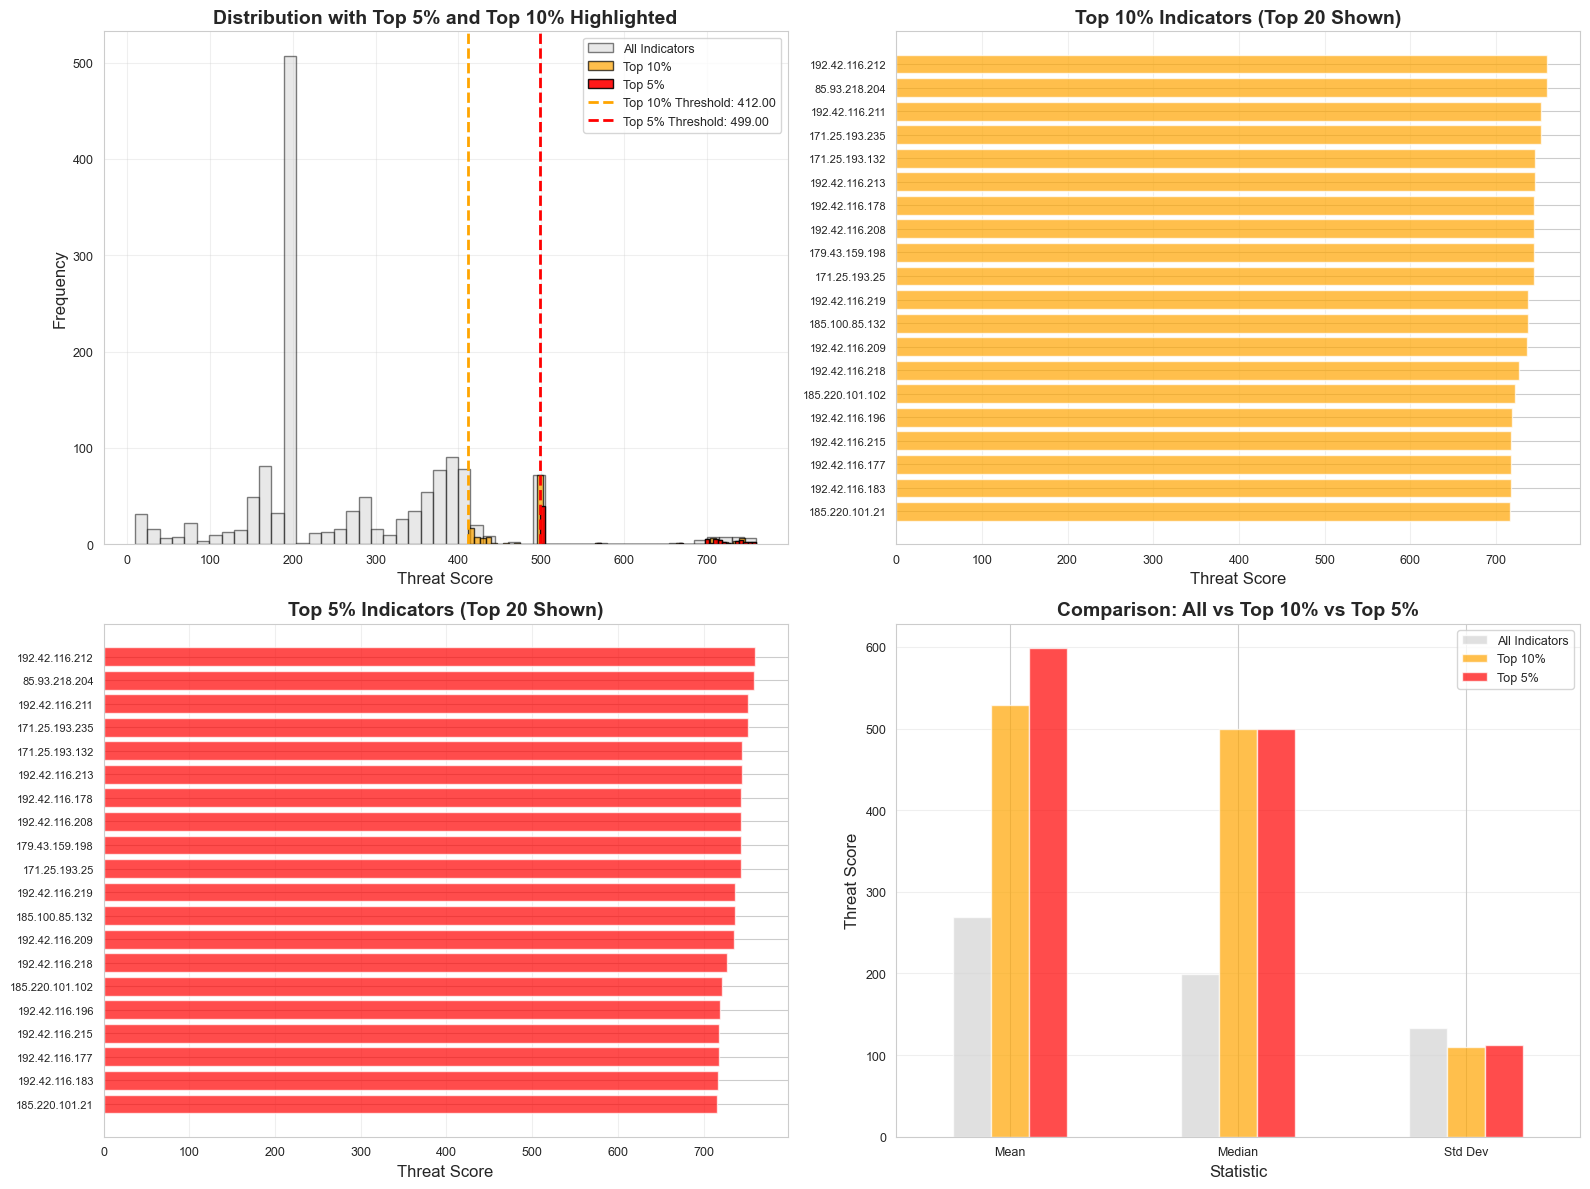


6. Top 10% Breakdown by Severity:
------------------------------------------------------------
medium: 112 indicators (77.24%)
high: 33 indicators (22.76%)

7. Top 5% Breakdown by Severity:
------------------------------------------------------------
medium: 40 indicators (54.79%)
high: 33 indicators (45.21%)

8. Top 10% Breakdown by Indicator Type:
------------------------------------------------------------
Address: 145 indicators (100.00%)

9. Top 5% Breakdown by Indicator Type:
------------------------------------------------------------
Address: 73 indicators (100.00%)

10. Partner Analysis for Top 10% Indicators:

10a. Partner Frequency in Top 10% Indicators:
------------------------------------------------------------
OS: 136 observations (13.17%)
CMS: 134 observations (12.97%)
FDA: 129 observations (12.49%)
HHS: 123 observations (11.91%)
VA: 121 observations (11.71%)
HRSA: 119 observations (11.52%)
IHS: 98 observations (9.49%)
NIH: 73 observations (7.07%)
DHA: 66 observations 

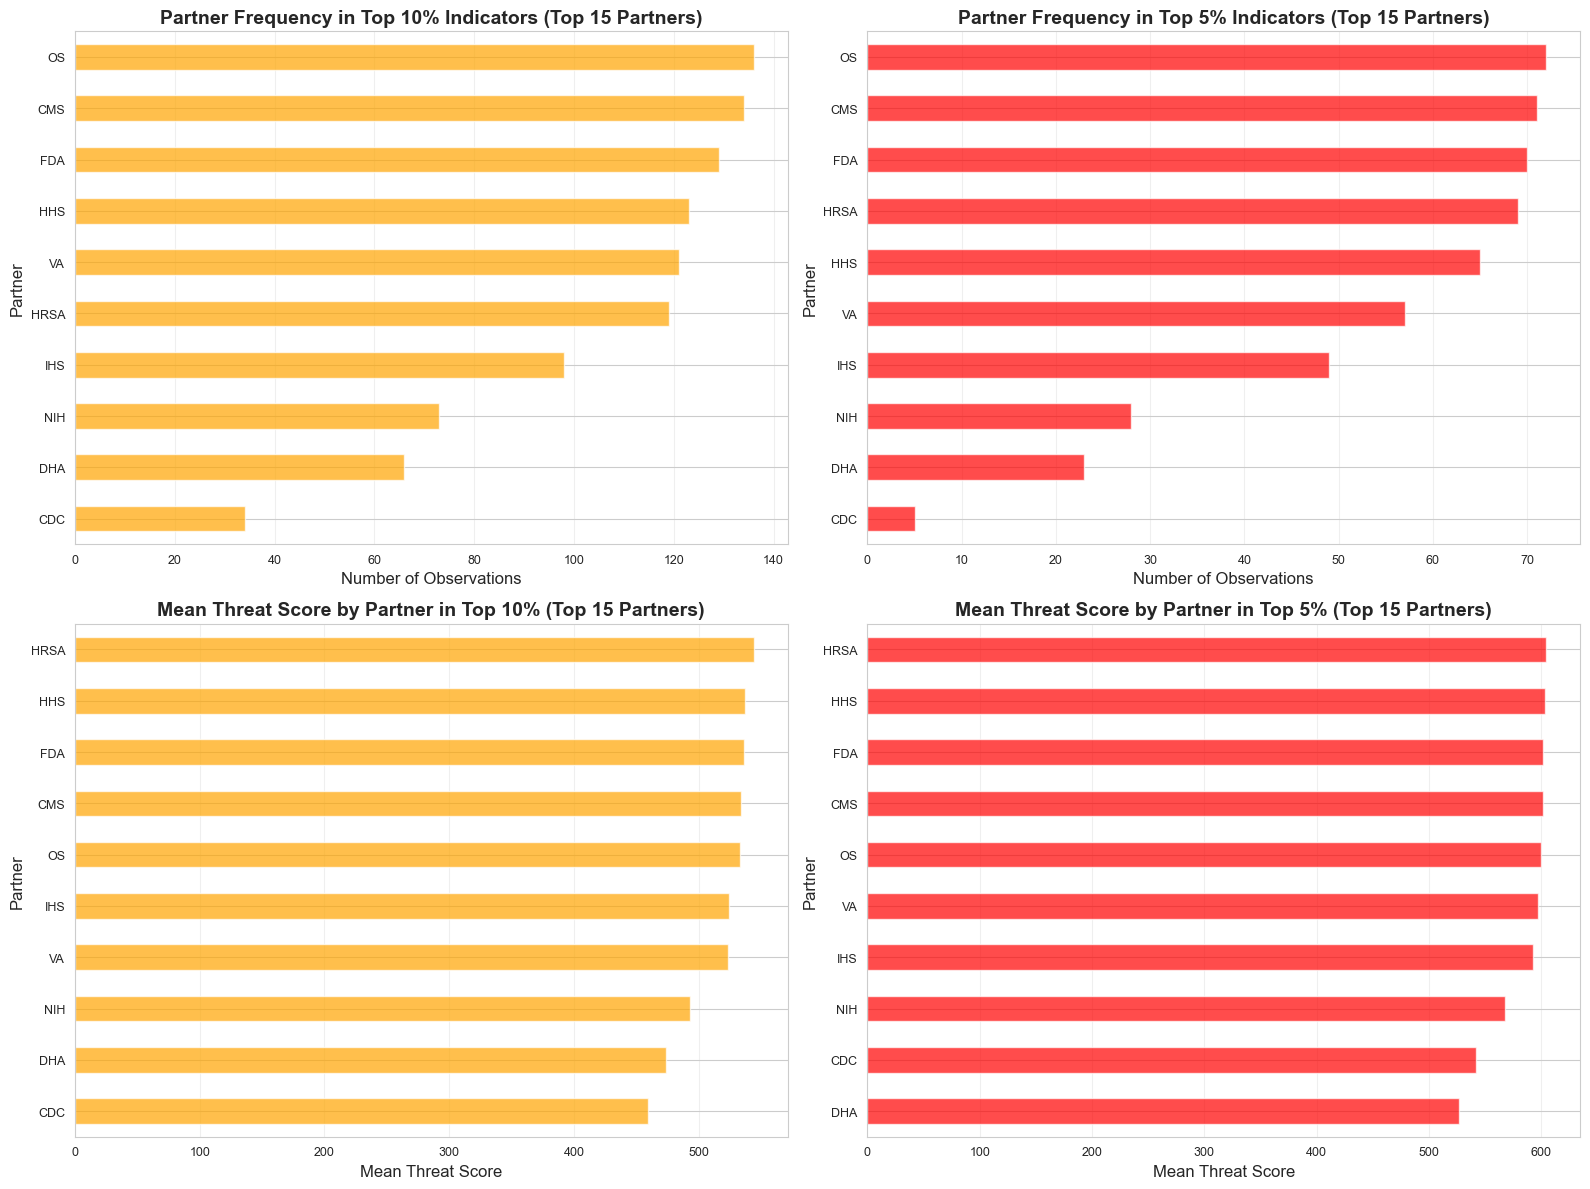


12. Partner Comparison: Top Percentiles vs Overall:

Top 15 Partners by Over-representation in Top 10%:
------------------------------------------------------------
            Overall_Pct  Top_10_Pct  Top_10_Over_Rep
Partners                                            
OS                10.80       13.17             2.36
FDA               10.35       12.49             2.14
CMS               11.06       12.97             1.91
HHS               10.17       11.91             1.74
HRSA               9.82       11.52             1.70
IHS                8.98        9.49             0.51
No Partner         0.32        0.00            -0.32
VA                12.50       11.71            -0.79
NIH                9.53        7.07            -2.46
CDC                5.84        3.29            -2.55
DHA               10.64        6.39            -4.25

Top 15 Partners by Over-representation in Top 5%:
------------------------------------------------------------
            Overall_Pct  Top_5_Pc

In [76]:
# Top 5% and Top 10% of Threat Scores and Indicators
print("=" * 60)
print("TOP 5% AND TOP 10% THREAT SCORES ANALYSIS")
print("=" * 60)

# Sort dataframe by Threat Score in descending order
df_sorted = df.sort_values('Threat Score', ascending=False).reset_index(drop=True)

# Calculate thresholds
total_indicators = len(df_sorted)
top_10_percent_count = int(np.ceil(total_indicators * 0.10))
top_5_percent_count = int(np.ceil(total_indicators * 0.05))

# Get top 10% and top 5%
top_10_percent = df_sorted.head(top_10_percent_count)
top_5_percent = df_sorted.head(top_5_percent_count)

# Calculate score thresholds
score_threshold_10 = top_10_percent['Threat Score'].min()
score_threshold_5 = top_5_percent['Threat Score'].min()

print(f"\n1. Overview:")
print("-" * 60)
print(f"Total Indicators: {total_indicators}")
print(f"Top 10% Count: {top_10_percent_count} indicators")
print(f"Top 5% Count: {top_5_percent_count} indicators")
print(f"\nScore Threshold for Top 10%: {score_threshold_10:.2f}")
print(f"Score Threshold for Top 5%: {score_threshold_5:.2f}")

# Statistics for top percentiles
print(f"\n2. Statistics - Top 10%:")
print("-" * 60)
print(f"Mean Score: {top_10_percent['Threat Score'].mean():.2f}")
print(f"Median Score: {top_10_percent['Threat Score'].median():.2f}")
print(f"Min Score: {top_10_percent['Threat Score'].min():.2f}")
print(f"Max Score: {top_10_percent['Threat Score'].max():.2f}")
print(f"Std Deviation: {top_10_percent['Threat Score'].std():.2f}")

print(f"\n3. Statistics - Top 5%:")
print("-" * 60)
print(f"Mean Score: {top_5_percent['Threat Score'].mean():.2f}")
print(f"Median Score: {top_5_percent['Threat Score'].median():.2f}")
print(f"Min Score: {top_5_percent['Threat Score'].min():.2f}")
print(f"Max Score: {top_5_percent['Threat Score'].max():.2f}")
print(f"Std Deviation: {top_5_percent['Threat Score'].std():.2f}")

# Display top 10% indicators
print(f"\n4. Top 10% Indicators ({top_10_percent_count} indicators):")
print("-" * 60)
display_cols = ['Indicator', 'Indicator Type', 'Partners', 'Threat Score', 'Severity', 
                'VirusTotal Malicious Score', 'Observation Yearly Count', 'ThreatConnect Rating']
# Only show columns that exist
display_cols = [col for col in display_cols if col in top_10_percent.columns]
print(top_10_percent[display_cols].to_string(index=False))

# Display top 5% indicators
print(f"\n5. Top 5% Indicators ({top_5_percent_count} indicators):")
print("-" * 60)
print(top_5_percent[display_cols].to_string(index=False))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10% and 5% highlighted in distribution
axes[0, 0].hist(df['Threat Score'], bins=50, edgecolor='black', alpha=0.5, color='lightgray', label='All Indicators')
axes[0, 0].hist(top_10_percent['Threat Score'], bins=50, edgecolor='black', alpha=0.7, color='orange', label='Top 10%')
axes[0, 0].hist(top_5_percent['Threat Score'], bins=50, edgecolor='black', alpha=0.9, color='red', label='Top 5%')
axes[0, 0].axvline(score_threshold_10, color='orange', linestyle='--', linewidth=2, label=f'Top 10% Threshold: {score_threshold_10:.2f}')
axes[0, 0].axvline(score_threshold_5, color='red', linestyle='--', linewidth=2, label=f'Top 5% Threshold: {score_threshold_5:.2f}')
axes[0, 0].set_xlabel('Threat Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution with Top 5% and Top 10% Highlighted', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 10% indicators bar chart
top_10_display = top_10_percent.head(20)  # Show top 20 for readability
axes[0, 1].barh(range(len(top_10_display)), top_10_display['Threat Score'].values, color='orange', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_10_display)))
axes[0, 1].set_yticklabels([f"{ind[:30]}..." if len(str(ind)) > 30 else str(ind) 
                            for ind in top_10_display['Indicator'].values], fontsize=8)
axes[0, 1].set_xlabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Top 10% Indicators (Top 20 Shown)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Top 5% indicators bar chart
top_5_display = top_5_percent.head(20)  # Show top 20 for readability
axes[1, 0].barh(range(len(top_5_display)), top_5_display['Threat Score'].values, color='red', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_5_display)))
axes[1, 0].set_yticklabels([f"{ind[:30]}..." if len(str(ind)) > 30 else str(ind) 
                            for ind in top_5_display['Indicator'].values], fontsize=8)
axes[1, 0].set_xlabel('Threat Score', fontsize=12)
axes[1, 0].set_title('Top 5% Indicators (Top 20 Shown)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# 4. Comparison: Top 5% vs Top 10% vs All
comparison_data = pd.DataFrame({
    'All Indicators': [df['Threat Score'].mean(), df['Threat Score'].median(), df['Threat Score'].std()],
    'Top 10%': [top_10_percent['Threat Score'].mean(), top_10_percent['Threat Score'].median(), top_10_percent['Threat Score'].std()],
    'Top 5%': [top_5_percent['Threat Score'].mean(), top_5_percent['Threat Score'].median(), top_5_percent['Threat Score'].std()]
}, index=['Mean', 'Median', 'Std Dev'])
comparison_data.plot(kind='bar', ax=axes[1, 1], color=['lightgray', 'orange', 'red'], alpha=0.7)
axes[1, 1].set_title('Comparison: All vs Top 10% vs Top 5%', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Threat Score', fontsize=12)
axes[1, 1].set_xlabel('Statistic', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Breakdown by other dimensions for top percentiles
print(f"\n6. Top 10% Breakdown by Severity:")
print("-" * 60)
if 'Severity' in top_10_percent.columns:
    severity_10 = top_10_percent['Severity'].value_counts()
    for severity, count in severity_10.items():
        percentage = (count / len(top_10_percent)) * 100
        print(f"{severity}: {count} indicators ({percentage:.2f}%)")

print(f"\n7. Top 5% Breakdown by Severity:")
print("-" * 60)
if 'Severity' in top_5_percent.columns:
    severity_5 = top_5_percent['Severity'].value_counts()
    for severity, count in severity_5.items():
        percentage = (count / len(top_5_percent)) * 100
        print(f"{severity}: {count} indicators ({percentage:.2f}%)")

print(f"\n8. Top 10% Breakdown by Indicator Type:")
print("-" * 60)
if 'Indicator Type' in top_10_percent.columns:
    type_10 = top_10_percent['Indicator Type'].value_counts()
    for ind_type, count in type_10.items():
        percentage = (count / len(top_10_percent)) * 100
        print(f"{ind_type}: {count} indicators ({percentage:.2f}%)")

print(f"\n9. Top 5% Breakdown by Indicator Type:")
print("-" * 60)
if 'Indicator Type' in top_5_percent.columns:
    type_5 = top_5_percent['Indicator Type'].value_counts()
    for ind_type, count in type_5.items():
        percentage = (count / len(top_5_percent)) * 100
        print(f"{ind_type}: {count} indicators ({percentage:.2f}%)")

# Partner Analysis for Top 5% and Top 10%
print(f"\n10. Partner Analysis for Top 10% Indicators:")
print("=" * 60)

# Handle missing partners and expand comma-separated partners
top_10_partners = top_10_percent.copy()
top_10_partners['Partners'] = top_10_partners['Partners'].fillna('No Partner')

# Expand partners if comma-separated
if top_10_partners['Partners'].astype(str).str.contains(',').any():
    top_10_expanded = top_10_partners.assign(Partners=top_10_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    top_10_expanded['Partners'] = top_10_expanded['Partners'].str.strip()
else:
    top_10_expanded = top_10_partners

# Partner counts for top 10%
print(f"\n10a. Partner Frequency in Top 10% Indicators:")
print("-" * 60)
partner_counts_10 = top_10_expanded['Partners'].value_counts()
for partner, count in partner_counts_10.items():
    percentage = (count / len(top_10_expanded)) * 100
    print(f"{partner}: {count} observations ({percentage:.2f}%)")

# Partner statistics for top 10%
print(f"\n10b. Partner Statistics in Top 10% Indicators:")
print("-" * 60)
partner_stats_10 = top_10_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean_Score', 'mean'),
    ('Median_Score', 'median'),
    ('Min_Score', 'min'),
    ('Max_Score', 'max')
]).round(2).sort_values('Count', ascending=False)
print(partner_stats_10)

print(f"\n11. Partner Analysis for Top 5% Indicators:")
print("=" * 60)

# Handle missing partners and expand comma-separated partners
top_5_partners = top_5_percent.copy()
top_5_partners['Partners'] = top_5_partners['Partners'].fillna('No Partner')

# Expand partners if comma-separated
if top_5_partners['Partners'].astype(str).str.contains(',').any():
    top_5_expanded = top_5_partners.assign(Partners=top_5_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    top_5_expanded['Partners'] = top_5_expanded['Partners'].str.strip()
else:
    top_5_expanded = top_5_partners

# Partner counts for top 5%
print(f"\n11a. Partner Frequency in Top 5% Indicators:")
print("-" * 60)
partner_counts_5 = top_5_expanded['Partners'].value_counts()
for partner, count in partner_counts_5.items():
    percentage = (count / len(top_5_expanded)) * 100
    print(f"{partner}: {count} observations ({percentage:.2f}%)")

# Partner statistics for top 5%
print(f"\n11b. Partner Statistics in Top 5% Indicators:")
print("-" * 60)
partner_stats_5 = top_5_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean_Score', 'mean'),
    ('Median_Score', 'median'),
    ('Min_Score', 'min'),
    ('Max_Score', 'max')
]).round(2).sort_values('Count', ascending=False)
print(partner_stats_5)

# Visualizations for partner analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Partner frequency in top 10%
top_partners_10 = partner_counts_10.head(15)
top_partners_10.plot(kind='barh', ax=axes[0, 0], color='orange', alpha=0.7)
axes[0, 0].set_title('Partner Frequency in Top 10% Indicators (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Observations', fontsize=12)
axes[0, 0].set_ylabel('Partner', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. Partner frequency in top 5%
top_partners_5 = partner_counts_5.head(15)
top_partners_5.plot(kind='barh', ax=axes[0, 1], color='red', alpha=0.7)
axes[0, 1].set_title('Partner Frequency in Top 5% Indicators (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Observations', fontsize=12)
axes[0, 1].set_ylabel('Partner', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Mean threat score by partner in top 10%
partner_means_10 = top_10_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(15)
partner_means_10.plot(kind='barh', ax=axes[1, 0], color='orange', alpha=0.7)
axes[1, 0].set_title('Mean Threat Score by Partner in Top 10% (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Mean Threat Score', fontsize=12)
axes[1, 0].set_ylabel('Partner', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# 4. Mean threat score by partner in top 5%
partner_means_5 = top_5_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(15)
partner_means_5.plot(kind='barh', ax=axes[1, 1], color='red', alpha=0.7)
axes[1, 1].set_title('Mean Threat Score by Partner in Top 5% (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Mean Threat Score', fontsize=12)
axes[1, 1].set_ylabel('Partner', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Comparison: Which partners appear most in top percentiles vs overall
print(f"\n12. Partner Comparison: Top Percentiles vs Overall:")
print("=" * 60)

# Get overall partner distribution (from earlier analysis if available, or calculate)
df_all_partners = df.copy()
df_all_partners['Partners'] = df_all_partners['Partners'].fillna('No Partner')
if df_all_partners['Partners'].astype(str).str.contains(',').any():
    df_all_expanded = df_all_partners.assign(Partners=df_all_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    df_all_expanded['Partners'] = df_all_expanded['Partners'].str.strip()
else:
    df_all_expanded = df_all_partners

overall_partner_counts = df_all_expanded['Partners'].value_counts()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Overall_Count': overall_partner_counts,
    'Top_10_Count': partner_counts_10,
    'Top_5_Count': partner_counts_5
}).fillna(0)

# Calculate percentages
comparison_df['Overall_Pct'] = (comparison_df['Overall_Count'] / len(df_all_expanded)) * 100
comparison_df['Top_10_Pct'] = (comparison_df['Top_10_Count'] / len(top_10_expanded)) * 100
comparison_df['Top_5_Pct'] = (comparison_df['Top_5_Count'] / len(top_5_expanded)) * 100

# Calculate over-representation
comparison_df['Top_10_Over_Rep'] = comparison_df['Top_10_Pct'] - comparison_df['Overall_Pct']
comparison_df['Top_5_Over_Rep'] = comparison_df['Top_5_Pct'] - comparison_df['Overall_Pct']

print("\nTop 15 Partners by Over-representation in Top 10%:")
print("-" * 60)
top_over_rep_10 = comparison_df.nlargest(15, 'Top_10_Over_Rep')[['Overall_Pct', 'Top_10_Pct', 'Top_10_Over_Rep']]
print(top_over_rep_10.round(2))

print("\nTop 15 Partners by Over-representation in Top 5%:")
print("-" * 60)
top_over_rep_5 = comparison_df.nlargest(15, 'Top_5_Over_Rep')[['Overall_Pct', 'Top_5_Pct', 'Top_5_Over_Rep']]
print(top_over_rep_5.round(2))


OBSERVATION PATTERN ANALYSIS FOR TOP INDICATORS

1. Available Observation-Related Columns:
------------------------------------------------------------
  - Last Observed
  - Observation Yearly Count
  - Observation Penalty Multiplier
  - Days_Since_Observed

2. Observation Yearly Count Analysis:

2a. Overall Statistics (All Indicators):
------------------------------------------------------------
Mean Observation Count: 78.04
Median Observation Count: 73.00
Std Deviation: 67.06
Min: 1.00
Max: 365.00

2b. Top 10% Indicators - Observation Count Statistics:
------------------------------------------------------------
Mean Observation Count: 91.03
Median Observation Count: 93.00
Std Deviation: 66.49
Min: 1.00
Max: 358.00

2c. Top 5% Indicators - Observation Count Statistics:
------------------------------------------------------------
Mean Observation Count: 101.10
Median Observation Count: 110.00
Std Deviation: 63.49
Min: 1.00
Max: 351.00

2d. Correlation Analysis:
-----------------------

C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3764065030.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_percent['Days_Since_Observed'] = (today - top_10_percent['Last Observed']).dt.days
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3764065030.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_percent['Days_Since_Observed'] = (today - top_5_percent['Last Observed']).dt.days
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3764065030.py:149: SettingWithCopyWarning: 
A value i

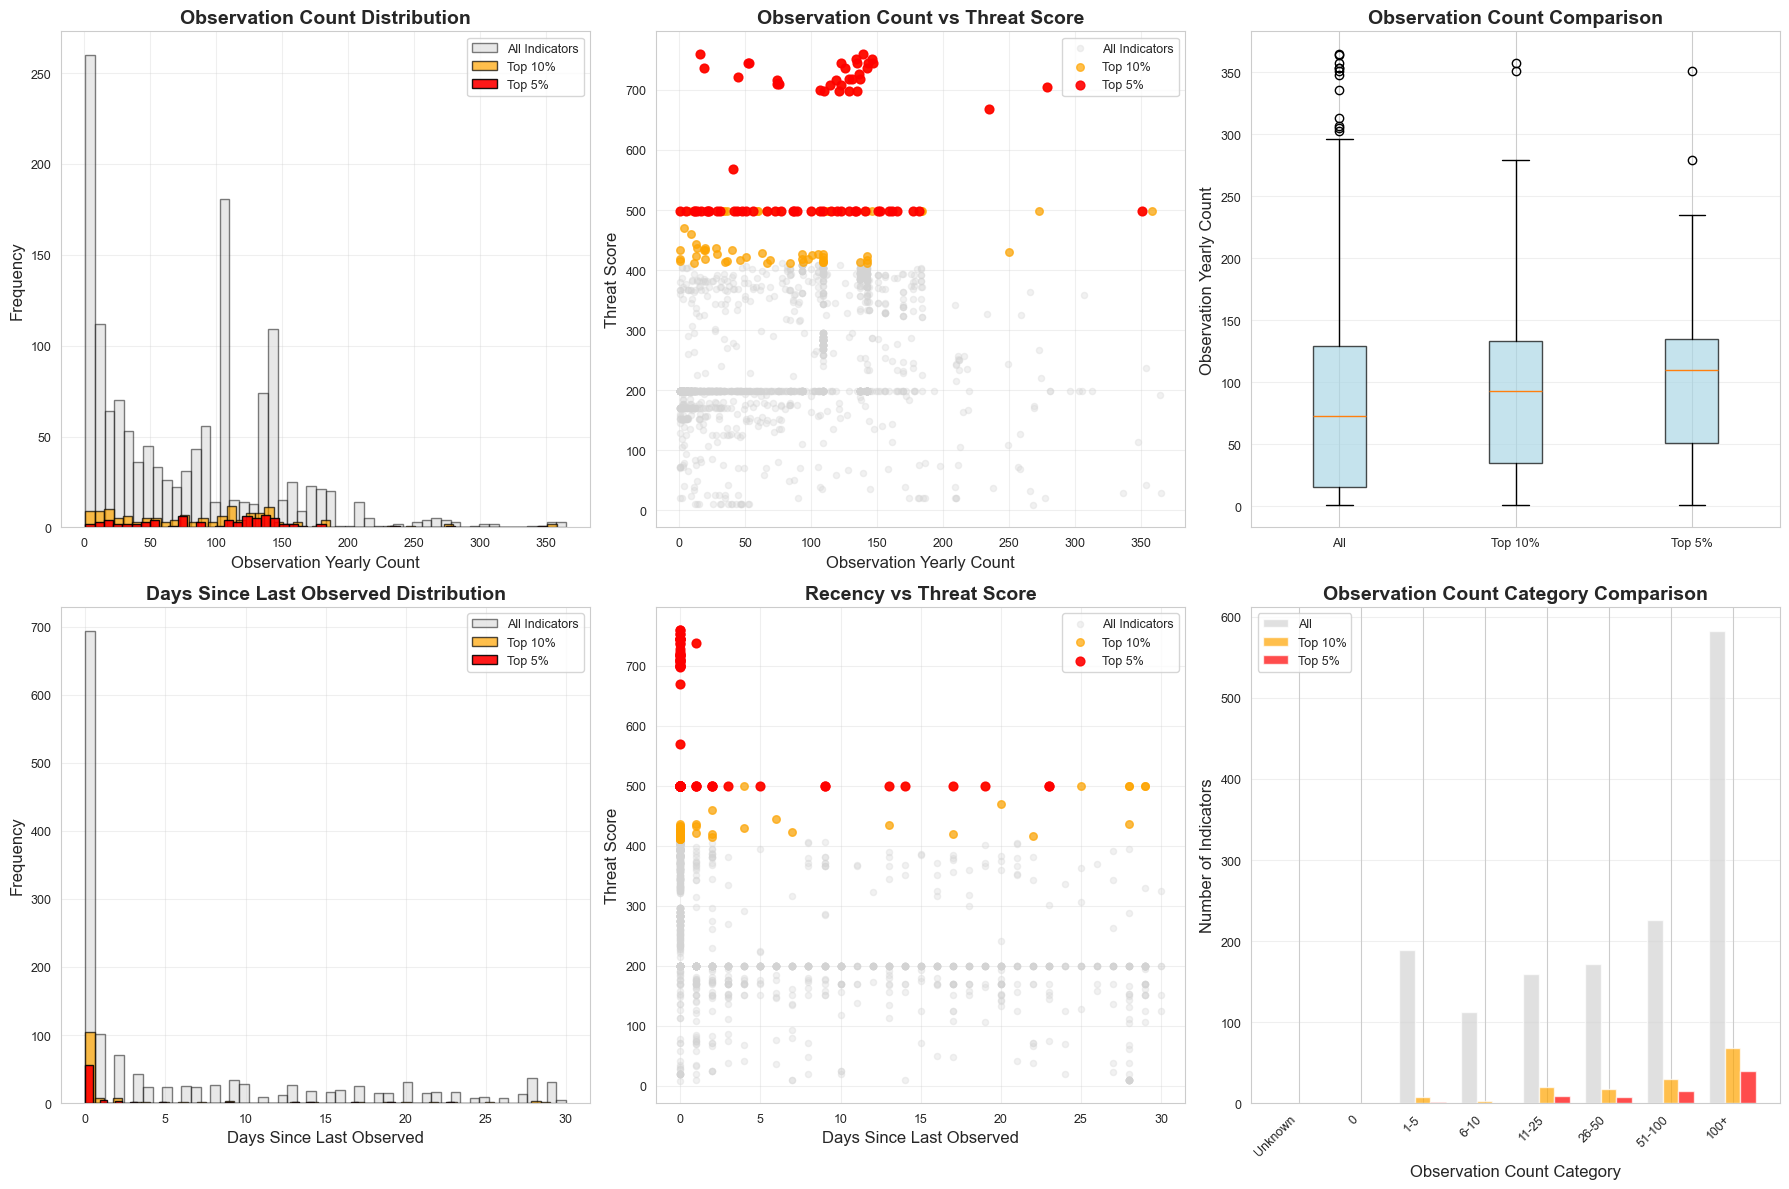


5. Summary of Common Observation Patterns:

Observation Count Pattern:
  - All Indicators Median: 73.00
  - Top 10% Median: 93.00 (Higher than overall)
  - Top 5% Median: 110.00 (Higher than overall)

Recency Pattern:
  - All Indicators Median Days Since Observed: 1.00
  - Top 10% Median Days: 0.00 (More Recent)
  - Top 5% Median Days: 0.00 (More Recent)


In [77]:
# Observation Pattern Analysis for Top 5% and Top 10% Indicators
print("=" * 60)
print("OBSERVATION PATTERN ANALYSIS FOR TOP INDICATORS")
print("=" * 60)

# Check available observation-related columns
obs_columns = [col for col in df.columns if 'observation' in col.lower() or 'observed' in col.lower() or 'count' in col.lower()]
print(f"\n1. Available Observation-Related Columns:")
print("-" * 60)
for col in obs_columns:
    print(f"  - {col}")

# Observation Yearly Count Analysis
if 'Observation Yearly Count' in df.columns:
    print(f"\n2. Observation Yearly Count Analysis:")
    print("=" * 60)
    
    # Statistics for all indicators
    print(f"\n2a. Overall Statistics (All Indicators):")
    print("-" * 60)
    print(f"Mean Observation Count: {df['Observation Yearly Count'].mean():.2f}")
    print(f"Median Observation Count: {df['Observation Yearly Count'].median():.2f}")
    print(f"Std Deviation: {df['Observation Yearly Count'].std():.2f}")
    print(f"Min: {df['Observation Yearly Count'].min():.2f}")
    print(f"Max: {df['Observation Yearly Count'].max():.2f}")
    
    # Statistics for top 10%
    print(f"\n2b. Top 10% Indicators - Observation Count Statistics:")
    print("-" * 60)
    top_10_obs = top_10_percent['Observation Yearly Count']
    print(f"Mean Observation Count: {top_10_obs.mean():.2f}")
    print(f"Median Observation Count: {top_10_obs.median():.2f}")
    print(f"Std Deviation: {top_10_obs.std():.2f}")
    print(f"Min: {top_10_obs.min():.2f}")
    print(f"Max: {top_10_obs.max():.2f}")
    
    # Statistics for top 5%
    print(f"\n2c. Top 5% Indicators - Observation Count Statistics:")
    print("-" * 60)
    top_5_obs = top_5_percent['Observation Yearly Count']
    print(f"Mean Observation Count: {top_5_obs.mean():.2f}")
    print(f"Median Observation Count: {top_5_obs.median():.2f}")
    print(f"Std Deviation: {top_5_obs.std():.2f}")
    print(f"Min: {top_5_obs.min():.2f}")
    print(f"Max: {top_5_obs.max():.2f}")
    
    # Correlation between observation count and threat score
    print(f"\n2d. Correlation Analysis:")
    print("-" * 60)
    corr_all = df['Observation Yearly Count'].corr(df['Threat Score'])
    corr_top10 = top_10_percent['Observation Yearly Count'].corr(top_10_percent['Threat Score'])
    corr_top5 = top_5_percent['Observation Yearly Count'].corr(top_5_percent['Threat Score'])
    print(f"Correlation (All Indicators): {corr_all:.3f}")
    print(f"Correlation (Top 10%): {corr_top10:.3f}")
    print(f"Correlation (Top 5%): {corr_top5:.3f}")

# Last Observed Analysis
if 'Last Observed' in df.columns:
    print(f"\n3. Last Observed Date Analysis:")
    print("=" * 60)
    
    # Calculate days since last observed (if conversion succeeded)
    if 'Last Observed' in df.columns:
        try:
            # Check if already datetime, if not convert
            if df['Last Observed'].dtype != 'datetime64[ns]':
                df['Last Observed'] = pd.to_datetime(df['Last Observed'], errors='coerce')
                top_10_percent['Last Observed'] = pd.to_datetime(top_10_percent['Last Observed'], errors='coerce')
                top_5_percent['Last Observed'] = pd.to_datetime(top_5_percent['Last Observed'], errors='coerce')
            
            today = pd.Timestamp.now()
            df['Days_Since_Observed'] = (today - df['Last Observed']).dt.days
            top_10_percent['Days_Since_Observed'] = (today - top_10_percent['Last Observed']).dt.days
            top_5_percent['Days_Since_Observed'] = (today - top_5_percent['Last Observed']).dt.days
            
            print(f"\n3a. Days Since Last Observed - All Indicators:")
            print("-" * 60)
            print(f"Mean: {df['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {df['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {df['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {df['Days_Since_Observed'].max():.2f} days")
            
            print(f"\n3b. Days Since Last Observed - Top 10%:")
            print("-" * 60)
            print(f"Mean: {top_10_percent['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {top_10_percent['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {top_10_percent['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {top_10_percent['Days_Since_Observed'].max():.2f} days")
            
            print(f"\n3c. Days Since Last Observed - Top 5%:")
            print("-" * 60)
            print(f"Mean: {top_5_percent['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {top_5_percent['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {top_5_percent['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {top_5_percent['Days_Since_Observed'].max():.2f} days")
            
            # Recent observation patterns
            print(f"\n3d. Recent Observation Patterns (Last 30/60/90 days):")
            print("-" * 60)
            recent_30_all = (df['Days_Since_Observed'] <= 30).sum()
            recent_60_all = (df['Days_Since_Observed'] <= 60).sum()
            recent_90_all = (df['Days_Since_Observed'] <= 90).sum()
            
            recent_30_top10 = (top_10_percent['Days_Since_Observed'] <= 30).sum()
            recent_60_top10 = (top_10_percent['Days_Since_Observed'] <= 60).sum()
            recent_90_top10 = (top_10_percent['Days_Since_Observed'] <= 90).sum()
            
            recent_30_top5 = (top_5_percent['Days_Since_Observed'] <= 30).sum()
            recent_60_top5 = (top_5_percent['Days_Since_Observed'] <= 60).sum()
            recent_90_top5 = (top_5_percent['Days_Since_Observed'] <= 90).sum()
            
            print(f"All Indicators - Observed in last 30 days: {recent_30_all} ({recent_30_all/len(df)*100:.2f}%)")
            print(f"All Indicators - Observed in last 60 days: {recent_60_all} ({recent_60_all/len(df)*100:.2f}%)")
            print(f"All Indicators - Observed in last 90 days: {recent_90_all} ({recent_90_all/len(df)*100:.2f}%)")
            print(f"\nTop 10% - Observed in last 30 days: {recent_30_top10} ({recent_30_top10/len(top_10_percent)*100:.2f}%)")
            print(f"Top 10% - Observed in last 60 days: {recent_60_top10} ({recent_60_top10/len(top_10_percent)*100:.2f}%)")
            print(f"Top 10% - Observed in last 90 days: {recent_90_top10} ({recent_90_top10/len(top_10_percent)*100:.2f}%)")
            print(f"\nTop 5% - Observed in last 30 days: {recent_30_top5} ({recent_30_top5/len(top_5_percent)*100:.2f}%)")
            print(f"Top 5% - Observed in last 60 days: {recent_60_top5} ({recent_60_top5/len(top_5_percent)*100:.2f}%)")
            print(f"Top 5% - Observed in last 90 days: {recent_90_top5} ({recent_90_top5/len(top_5_percent)*100:.2f}%)")
        except Exception as e:
            print(f"Error processing date information: {e}")

# Observation Count Distribution Analysis
if 'Observation Yearly Count' in df.columns:
    print(f"\n4. Observation Count Distribution Patterns:")
    print("=" * 60)
    
    # Categorize observation counts
    def categorize_obs_count(count):
        if pd.isna(count):
            return 'Unknown'
        elif count == 0:
            return '0'
        elif count <= 5:
            return '1-5'
        elif count <= 10:
            return '6-10'
        elif count <= 25:
            return '11-25'
        elif count <= 50:
            return '26-50'
        elif count <= 100:
            return '51-100'
        else:
            return '100+'
    
    df['Obs_Category'] = df['Observation Yearly Count'].apply(categorize_obs_count)
    top_10_percent['Obs_Category'] = top_10_percent['Observation Yearly Count'].apply(categorize_obs_count)
    top_5_percent['Obs_Category'] = top_5_percent['Observation Yearly Count'].apply(categorize_obs_count)
    
    print(f"\n4a. Observation Count Categories - All Indicators:")
    print("-" * 60)
    obs_cat_all = df['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_all.items():
        print(f"{cat}: {count} indicators ({count/len(df)*100:.2f}%)")
    
    print(f"\n4b. Observation Count Categories - Top 10%:")
    print("-" * 60)
    obs_cat_top10 = top_10_percent['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_top10.items():
        print(f"{cat}: {count} indicators ({count/len(top_10_percent)*100:.2f}%)")
    
    print(f"\n4c. Observation Count Categories - Top 5%:")
    print("-" * 60)
    obs_cat_top5 = top_5_percent['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_top5.items():
        print(f"{cat}: {count} indicators ({count/len(top_5_percent)*100:.2f}%)")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Observation Count Distribution - All vs Top 10% vs Top 5%
if 'Observation Yearly Count' in df.columns:
    axes[0, 0].hist(df['Observation Yearly Count'], bins=50, alpha=0.5, color='lightgray', label='All Indicators', edgecolor='black')
    axes[0, 0].hist(top_10_percent['Observation Yearly Count'], bins=50, alpha=0.7, color='orange', label='Top 10%', edgecolor='black')
    axes[0, 0].hist(top_5_percent['Observation Yearly Count'], bins=50, alpha=0.9, color='red', label='Top 5%', edgecolor='black')
    axes[0, 0].set_xlabel('Observation Yearly Count', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Observation Count Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Scatter: Observation Count vs Threat Score
    axes[0, 1].scatter(df['Observation Yearly Count'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
    axes[0, 1].scatter(top_10_percent['Observation Yearly Count'], top_10_percent['Threat Score'], alpha=0.7, color='orange', s=30, label='Top 10%')
    axes[0, 1].scatter(top_5_percent['Observation Yearly Count'], top_5_percent['Threat Score'], alpha=0.9, color='red', s=40, label='Top 5%')
    axes[0, 1].set_xlabel('Observation Yearly Count', fontsize=12)
    axes[0, 1].set_ylabel('Threat Score', fontsize=12)
    axes[0, 1].set_title('Observation Count vs Threat Score', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Box plot: Observation Count by Group
    obs_data = [
        df['Observation Yearly Count'].dropna(),
        top_10_percent['Observation Yearly Count'].dropna(),
        top_5_percent['Observation Yearly Count'].dropna()
    ]
    axes[0, 2].boxplot(obs_data, labels=['All', 'Top 10%', 'Top 5%'], patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[0, 2].set_ylabel('Observation Yearly Count', fontsize=12)
    axes[0, 2].set_title('Observation Count Comparison', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Days Since Last Observed (if available)
if 'Last Observed' in df.columns and 'Days_Since_Observed' in df.columns:
    axes[1, 0].hist(df['Days_Since_Observed'].dropna(), bins=50, alpha=0.5, color='lightgray', label='All Indicators', edgecolor='black')
    axes[1, 0].hist(top_10_percent['Days_Since_Observed'].dropna(), bins=50, alpha=0.7, color='orange', label='Top 10%', edgecolor='black')
    axes[1, 0].hist(top_5_percent['Days_Since_Observed'].dropna(), bins=50, alpha=0.9, color='red', label='Top 5%', edgecolor='black')
    axes[1, 0].set_xlabel('Days Since Last Observed', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Days Since Last Observed Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Scatter: Days Since Observed vs Threat Score
    axes[1, 1].scatter(df['Days_Since_Observed'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
    axes[1, 1].scatter(top_10_percent['Days_Since_Observed'], top_10_percent['Threat Score'], alpha=0.7, color='orange', s=30, label='Top 10%')
    axes[1, 1].scatter(top_5_percent['Days_Since_Observed'], top_5_percent['Threat Score'], alpha=0.9, color='red', s=40, label='Top 5%')
    axes[1, 1].set_xlabel('Days Since Last Observed', fontsize=12)
    axes[1, 1].set_ylabel('Threat Score', fontsize=12)
    axes[1, 1].set_title('Recency vs Threat Score', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

# 6. Observation Category Comparison
if 'Obs_Category' in df.columns:
    cat_order = ['Unknown', '0', '1-5', '6-10', '11-25', '26-50', '51-100', '100+']
    cat_all = df['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    cat_top10 = top_10_percent['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    cat_top5 = top_5_percent['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    
    x = np.arange(len(cat_order))
    width = 0.25
    axes[1, 2].bar(x - width, cat_all.values, width, label='All', color='lightgray', alpha=0.7)
    axes[1, 2].bar(x, cat_top10.values, width, label='Top 10%', color='orange', alpha=0.7)
    axes[1, 2].bar(x + width, cat_top5.values, width, label='Top 5%', color='red', alpha=0.7)
    axes[1, 2].set_xlabel('Observation Count Category', fontsize=12)
    axes[1, 2].set_ylabel('Number of Indicators', fontsize=12)
    axes[1, 2].set_title('Observation Count Category Comparison', fontsize=14, fontweight='bold')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(cat_order, rotation=45, ha='right')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary of Common Patterns
print(f"\n5. Summary of Common Observation Patterns:")
print("=" * 60)
if 'Observation Yearly Count' in df.columns:
    top10_median_obs = top_10_percent['Observation Yearly Count'].median()
    top5_median_obs = top_5_percent['Observation Yearly Count'].median()
    all_median_obs = df['Observation Yearly Count'].median()
    
    print(f"\nObservation Count Pattern:")
    print(f"  - All Indicators Median: {all_median_obs:.2f}")
    print(f"  - Top 10% Median: {top10_median_obs:.2f} ({'Higher' if top10_median_obs > all_median_obs else 'Lower'} than overall)")
    print(f"  - Top 5% Median: {top5_median_obs:.2f} ({'Higher' if top5_median_obs > all_median_obs else 'Lower'} than overall)")

if 'Days_Since_Observed' in df.columns:
    top10_median_days = top_10_percent['Days_Since_Observed'].median()
    top5_median_days = top_5_percent['Days_Since_Observed'].median()
    all_median_days = df['Days_Since_Observed'].median()
    
    print(f"\nRecency Pattern:")
    print(f"  - All Indicators Median Days Since Observed: {all_median_days:.2f}")
    print(f"  - Top 10% Median Days: {top10_median_days:.2f} ({'More Recent' if top10_median_days < all_median_days else 'Less Recent'})")
    print(f"  - Top 5% Median Days: {top5_median_days:.2f} ({'More Recent' if top5_median_days < all_median_days else 'Less Recent'})")


MULTIPLE PARTNERS ANALYSIS

1. Partner Count Statistics:

1a. All Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 6.24
Median Number of Partners: 7.00
Std Deviation: 3.34
Min: 0
Max: 10

1b. Top 10% Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 7.12
Median Number of Partners: 7.00
Std Deviation: 2.10
Min: 1
Max: 10

1c. Top 5% Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 6.97
Median Number of Partners: 7.00
Std Deviation: 1.48
Min: 1
Max: 10

2. Partner Count Distribution:

2a. All Indicators - Partner Count Distribution:
------------------------------------------------------------
0 partner(s): 29 indicators (2.01%)
1 partner(s): 158 indicators (10.96%)
2 partner(s): 100 indicators (6.94%)
3 partner(s): 108 indicators (7.49%)
4 partner(s): 93 indicators (6.45%)
5 partner(s): 107 indica

C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3866736827.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_percent['Partner_Count'] = top_10_percent['Partners'].apply(count_partners)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3866736827.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_percent['Partner_Count'] = top_5_percent['Partners'].apply(count_partners)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\3866736827.py:177: MatplotlibDeprecationWarning: The 'labels' param

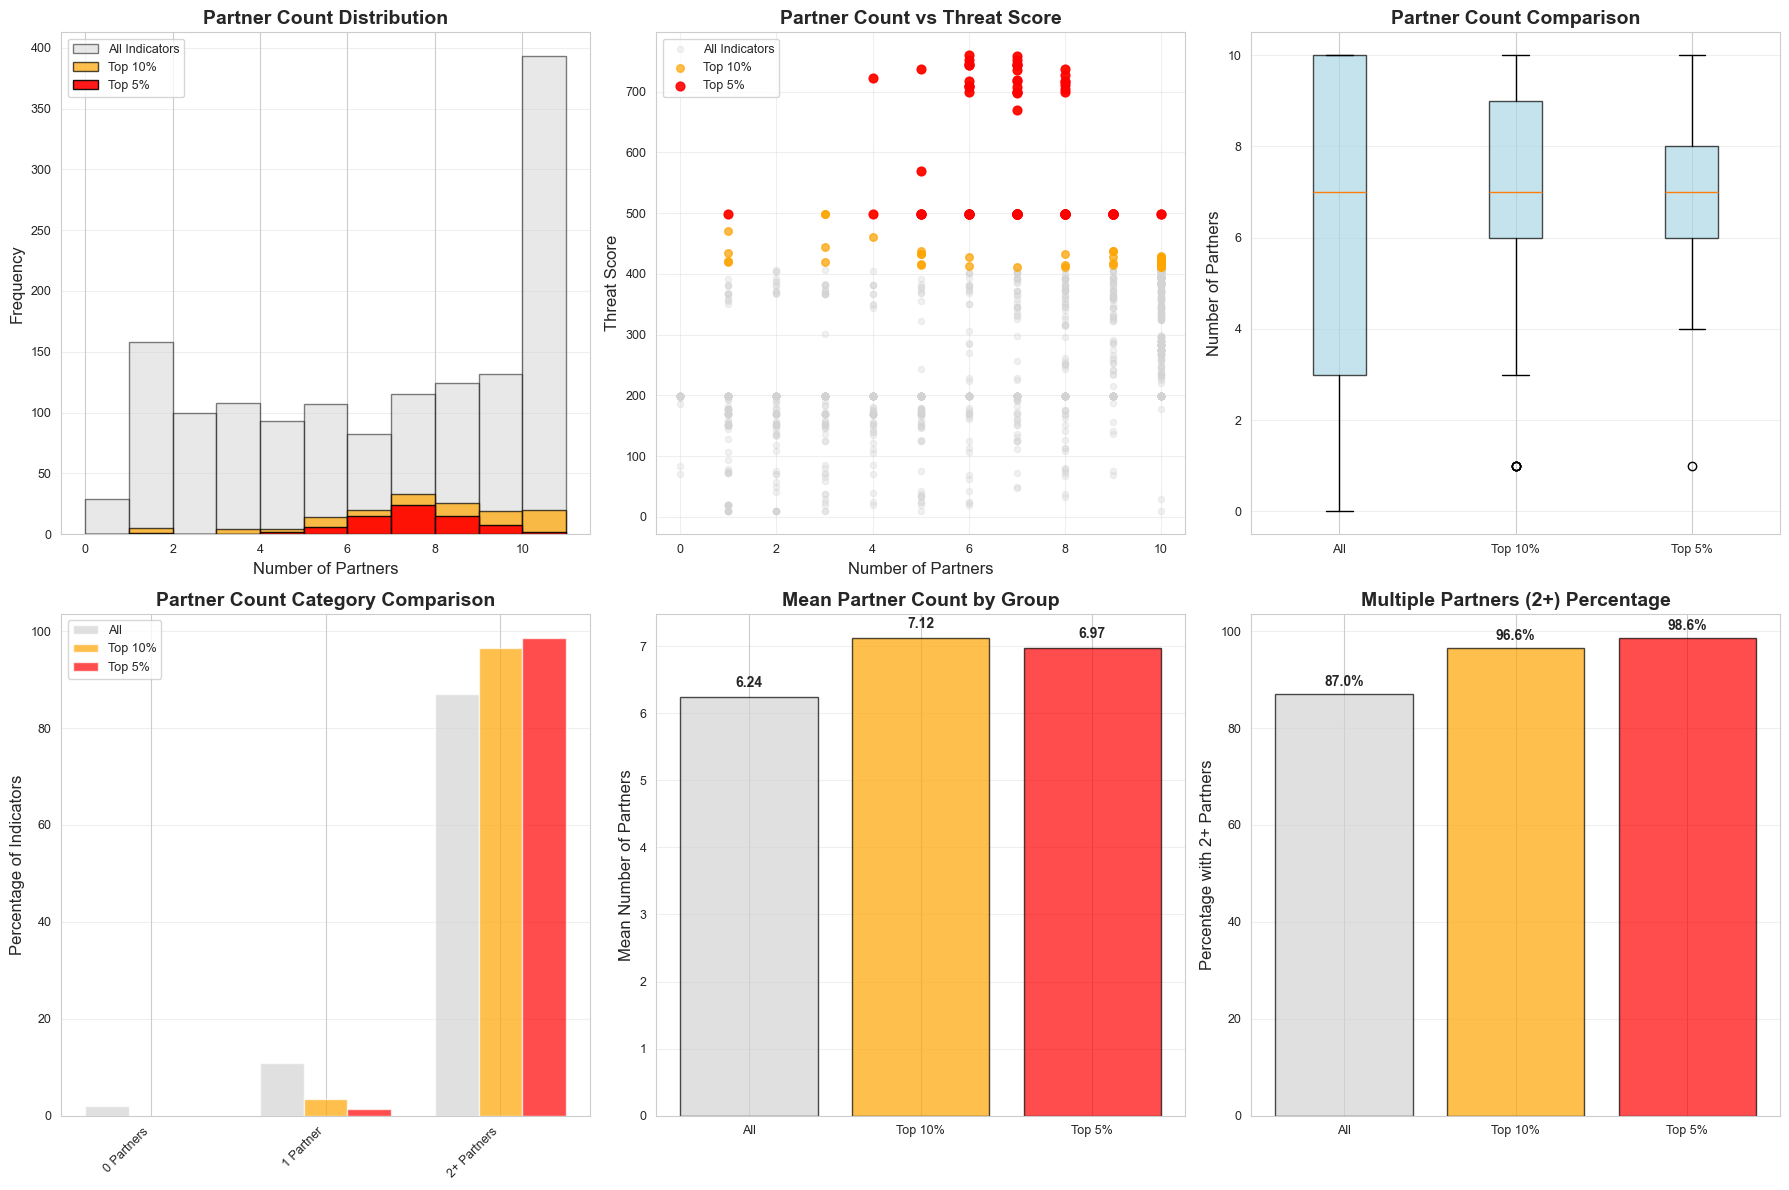


5. Summary:
✓ Top 10% indicators have MORE partners on average (7.12 vs 6.24)
✓ Top 5% indicators have MORE partners on average (6.97 vs 6.24)
✓ Top 10% indicators are MORE likely to have 2+ partners (96.55% vs 87.02%)
✓ Top 5% indicators are MORE likely to have 2+ partners (98.63% vs 87.02%)


In [78]:
# Multiple Partners Analysis for Top 5% and Top 10% Indicators
print("=" * 60)
print("MULTIPLE PARTNERS ANALYSIS")
print("=" * 60)

# Function to count number of partners
def count_partners(partner_string):
    if pd.isna(partner_string) or partner_string == '' or str(partner_string).strip() == '':
        return 0
    # Split by comma and count non-empty partners
    partners = str(partner_string).split(',')
    return len([p for p in partners if p.strip() != ''])

# Count partners for all indicators
df['Partner_Count'] = df['Partners'].apply(count_partners)
top_10_percent['Partner_Count'] = top_10_percent['Partners'].apply(count_partners)
top_5_percent['Partner_Count'] = top_5_percent['Partners'].apply(count_partners)

print(f"\n1. Partner Count Statistics:")
print("=" * 60)

print(f"\n1a. All Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {df['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {df['Partner_Count'].median():.2f}")
print(f"Std Deviation: {df['Partner_Count'].std():.2f}")
print(f"Min: {df['Partner_Count'].min()}")
print(f"Max: {df['Partner_Count'].max()}")

print(f"\n1b. Top 10% Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {top_10_percent['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {top_10_percent['Partner_Count'].median():.2f}")
print(f"Std Deviation: {top_10_percent['Partner_Count'].std():.2f}")
print(f"Min: {top_10_percent['Partner_Count'].min()}")
print(f"Max: {top_10_percent['Partner_Count'].max()}")

print(f"\n1c. Top 5% Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {top_5_percent['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {top_5_percent['Partner_Count'].median():.2f}")
print(f"Std Deviation: {top_5_percent['Partner_Count'].std():.2f}")
print(f"Min: {top_5_percent['Partner_Count'].min()}")
print(f"Max: {top_5_percent['Partner_Count'].max()}")

# Distribution of partner counts
print(f"\n2. Partner Count Distribution:")
print("=" * 60)

print(f"\n2a. All Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_all = df['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_all.items():
    percentage = (num_indicators / len(df)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

print(f"\n2b. Top 10% Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_top10 = top_10_percent['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_top10.items():
    percentage = (num_indicators / len(top_10_percent)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

print(f"\n2c. Top 5% Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_top5 = top_5_percent['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_top5.items():
    percentage = (num_indicators / len(top_5_percent)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

# Multiple partners analysis (2+ partners)
print(f"\n3. Multiple Partners (2+ Partners) Analysis:")
print("=" * 60)

multiple_all = (df['Partner_Count'] >= 2).sum()
multiple_top10 = (top_10_percent['Partner_Count'] >= 2).sum()
multiple_top5 = (top_5_percent['Partner_Count'] >= 2).sum()

single_all = (df['Partner_Count'] == 1).sum()
single_top10 = (top_10_percent['Partner_Count'] == 1).sum()
single_top5 = (top_5_percent['Partner_Count'] == 1).sum()

none_all = (df['Partner_Count'] == 0).sum()
none_top10 = (top_10_percent['Partner_Count'] == 0).sum()
none_top5 = (top_5_percent['Partner_Count'] == 0).sum()

print(f"\n3a. All Indicators:")
print("-" * 60)
print(f"0 partners: {none_all} ({none_all/len(df)*100:.2f}%)")
print(f"1 partner: {single_all} ({single_all/len(df)*100:.2f}%)")
print(f"2+ partners: {multiple_all} ({multiple_all/len(df)*100:.2f}%)")

print(f"\n3b. Top 10% Indicators:")
print("-" * 60)
print(f"0 partners: {none_top10} ({none_top10/len(top_10_percent)*100:.2f}%)")
print(f"1 partner: {single_top10} ({single_top10/len(top_10_percent)*100:.2f}%)")
print(f"2+ partners: {multiple_top10} ({multiple_top10/len(top_10_percent)*100:.2f}%)")

print(f"\n3c. Top 5% Indicators:")
print("-" * 60)
print(f"0 partners: {none_top5} ({none_top5/len(top_5_percent)*100:.2f}%)")
print(f"1 partner: {single_top5} ({single_top5/len(top_5_percent)*100:.2f}%)")
print(f"2+ partners: {multiple_top5} ({multiple_top5/len(top_5_percent)*100:.2f}%)")

# Statistical comparison
print(f"\n4. Statistical Comparison:")
print("=" * 60)
mean_all = df['Partner_Count'].mean()
mean_top10 = top_10_percent['Partner_Count'].mean()
mean_top5 = top_5_percent['Partner_Count'].mean()

pct_diff_top10 = ((mean_top10 - mean_all) / mean_all * 100) if mean_all > 0 else 0
pct_diff_top5 = ((mean_top5 - mean_all) / mean_all * 100) if mean_all > 0 else 0

print(f"\n4a. Mean Partner Count Comparison:")
print("-" * 60)
print(f"All Indicators: {mean_all:.2f}")
print(f"Top 10%: {mean_top10:.2f} ({'+' if pct_diff_top10 > 0 else ''}{pct_diff_top10:.2f}% difference)")
print(f"Top 5%: {mean_top5:.2f} ({'+' if pct_diff_top5 > 0 else ''}{pct_diff_top5:.2f}% difference)")

# Multiple partners percentage
pct_multiple_all = (multiple_all / len(df)) * 100
pct_multiple_top10 = (multiple_top10 / len(top_10_percent)) * 100
pct_multiple_top5 = (multiple_top5 / len(top_5_percent)) * 100

print(f"\n4b. Percentage with 2+ Partners:")
print("-" * 60)
print(f"All Indicators: {pct_multiple_all:.2f}%")
print(f"Top 10%: {pct_multiple_top10:.2f}% ({'+' if pct_multiple_top10 > pct_multiple_all else ''}{pct_multiple_top10 - pct_multiple_all:.2f} percentage points)")
print(f"Top 5%: {pct_multiple_top5:.2f}% ({'+' if pct_multiple_top5 > pct_multiple_all else ''}{pct_multiple_top5 - pct_multiple_all:.2f} percentage points)")

# Correlation between partner count and threat score
corr_partner_score = df['Partner_Count'].corr(df['Threat Score'])
corr_partner_score_top10 = top_10_percent['Partner_Count'].corr(top_10_percent['Threat Score'])
corr_partner_score_top5 = top_5_percent['Partner_Count'].corr(top_5_percent['Threat Score'])

print(f"\n4c. Correlation: Partner Count vs Threat Score:")
print("-" * 60)
print(f"All Indicators: {corr_partner_score:.3f}")
print(f"Top 10%: {corr_partner_score_top10:.3f}")
print(f"Top 5%: {corr_partner_score_top5:.3f}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Partner Count Distribution - Histogram
axes[0, 0].hist(df['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.5, 
                color='lightgray', label='All Indicators', edgecolor='black')
axes[0, 0].hist(top_10_percent['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.7, 
                color='orange', label='Top 10%', edgecolor='black')
axes[0, 0].hist(top_5_percent['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.9, 
                color='red', label='Top 5%', edgecolor='black')
axes[0, 0].set_xlabel('Number of Partners', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Partner Count Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Scatter: Partner Count vs Threat Score
axes[0, 1].scatter(df['Partner_Count'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
axes[0, 1].scatter(top_10_percent['Partner_Count'], top_10_percent['Threat Score'], alpha=0.7, 
                   color='orange', s=30, label='Top 10%')
axes[0, 1].scatter(top_5_percent['Partner_Count'], top_5_percent['Threat Score'], alpha=0.9, 
                   color='red', s=40, label='Top 5%')
axes[0, 1].set_xlabel('Number of Partners', fontsize=12)
axes[0, 1].set_ylabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Partner Count vs Threat Score', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Box Plot: Partner Count by Group
partner_data = [
    df['Partner_Count'],
    top_10_percent['Partner_Count'],
    top_5_percent['Partner_Count']
]
axes[0, 2].boxplot(partner_data, labels=['All', 'Top 10%', 'Top 5%'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 2].set_ylabel('Number of Partners', fontsize=12)
axes[0, 2].set_title('Partner Count Comparison', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Multiple Partners (2+) Comparison
categories = ['0 Partners', '1 Partner', '2+ Partners']
all_values = [none_all/len(df)*100, single_all/len(df)*100, multiple_all/len(df)*100]
top10_values = [none_top10/len(top_10_percent)*100, single_top10/len(top_10_percent)*100, multiple_top10/len(top_10_percent)*100]
top5_values = [none_top5/len(top_5_percent)*100, single_top5/len(top_5_percent)*100, multiple_top5/len(top_5_percent)*100]

x = np.arange(len(categories))
width = 0.25
axes[1, 0].bar(x - width, all_values, width, label='All', color='lightgray', alpha=0.7)
axes[1, 0].bar(x, top10_values, width, label='Top 10%', color='orange', alpha=0.7)
axes[1, 0].bar(x + width, top5_values, width, label='Top 5%', color='red', alpha=0.7)
axes[1, 0].set_ylabel('Percentage of Indicators', fontsize=12)
axes[1, 0].set_title('Partner Count Category Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Mean Partner Count Comparison
means = [mean_all, mean_top10, mean_top5]
colors = ['lightgray', 'orange', 'red']
axes[1, 1].bar(['All', 'Top 10%', 'Top 5%'], means, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Mean Number of Partners', fontsize=12)
axes[1, 1].set_title('Mean Partner Count by Group', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(means):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 6. Percentage with 2+ Partners
pct_multiple = [pct_multiple_all, pct_multiple_top10, pct_multiple_top5]
axes[1, 2].bar(['All', 'Top 10%', 'Top 5%'], pct_multiple, color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('Percentage with 2+ Partners', fontsize=12)
axes[1, 2].set_title('Multiple Partners (2+) Percentage', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(pct_multiple):
    axes[1, 2].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print(f"\n5. Summary:")
print("=" * 60)
if mean_top10 > mean_all:
    print(f"✓ Top 10% indicators have MORE partners on average ({mean_top10:.2f} vs {mean_all:.2f})")
else:
    print(f"✗ Top 10% indicators have FEWER partners on average ({mean_top10:.2f} vs {mean_all:.2f})")

if mean_top5 > mean_all:
    print(f"✓ Top 5% indicators have MORE partners on average ({mean_top5:.2f} vs {mean_all:.2f})")
else:
    print(f"✗ Top 5% indicators have FEWER partners on average ({mean_top5:.2f} vs {mean_all:.2f})")

if pct_multiple_top10 > pct_multiple_all:
    print(f"✓ Top 10% indicators are MORE likely to have 2+ partners ({pct_multiple_top10:.2f}% vs {pct_multiple_all:.2f}%)")
else:
    print(f"✗ Top 10% indicators are LESS likely to have 2+ partners ({pct_multiple_top10:.2f}% vs {pct_multiple_all:.2f}%)")

if pct_multiple_top5 > pct_multiple_all:
    print(f"✓ Top 5% indicators are MORE likely to have 2+ partners ({pct_multiple_top5:.2f}% vs {pct_multiple_all:.2f}%)")
else:
    print(f"✗ Top 5% indicators are LESS likely to have 2+ partners ({pct_multiple_top5:.2f}% vs {pct_multiple_all:.2f}%)")


In [ ]:
# Generate PDF Executive Report
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import os

# Define HHS Standard Colors
HHS_COLORS = {
    'blue': '#003366',      # HHS Primary Blue
    'teal': '#007FA3',      # HHS Teal
    'green': '#4A9B44',     # HHS Green
    'orange': '#F47B20',    # HHS Orange
    'red': '#C8102E',       # HHS Red
    'gray': '#6C757D',      # HHS Gray
    'light_gray': '#D3D3D3', # Light Gray for backgrounds
    'dark_blue': '#001F3F'  # Darker Blue for emphasis
}

# Create PDF file
report_filename = f'Threat_Assessment_Score_Report_Last30Days_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pdf'
pdf = PdfPages(report_filename)

# Set up figure style - compact sizing for better fit
plt.rcParams['figure.figsize'] = (10, 7.5)  # Slightly smaller than letter size
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# ============================================================================
# PAGE 1: TITLE PAGE
# ============================================================================
fig = plt.figure(figsize=(10, 7.5))
ax = fig.add_subplot(111)
ax.axis('off')

title_text = "THREAT ASSESSMENT SCORES\nANALYSIS REPORT"
ax.text(0.5, 0.75, title_text, ha='center', va='center', fontsize=26, fontweight='bold',
        transform=ax.transAxes)

subtitle = f"Analysis Date: {datetime.now().strftime('%B %d, %Y')}\n\n"
subtitle += f"Total Indicators Analyzed: {len(df):,}\n"
subtitle += f"(Last Observed in Last 30 Days)"
ax.text(0.5, 0.50, subtitle, ha='center', va='center', fontsize=13,
        transform=ax.transAxes)

pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# ============================================================================
# PAGE 2: EXECUTIVE SUMMARY
# ============================================================================
fig = plt.figure(figsize=(10, 7.5))
ax = fig.add_subplot(111)
ax.axis('off')

y_pos = 0.98
ax.text(0.1, y_pos, "EXECUTIVE SUMMARY", fontsize=18, fontweight='bold', transform=ax.transAxes)
y_pos -= 0.07

summary_points = [
    f"• Analyzed {len(df):,} threat indicators observed in the last 30 days",
    f"• Identified {top_10_percent_count} highest-priority indicators (top 10%)",
    f"• Found that high-scoring threats are observed by more partner organizations",
    f"• Discovered that frequently observed threats are significantly more likely to be high-scoring",
    f"• Top 10% indicators median {top_10_percent['Threat Score'].median():.0f} vs {df['Threat Score'].median():.0f} overall",
    f"• Analysis focuses on recent, active threats (last 30 days only)"
]

for point in summary_points:
    ax.text(0.1, y_pos, point, fontsize=10, transform=ax.transAxes)
    y_pos -= 0.055

y_pos -= 0.03
ax.text(0.1, y_pos, "KEY FINDINGS:", fontsize=13, fontweight='bold', transform=ax.transAxes)
y_pos -= 0.055

findings = [
    "1. Multi-Partner Observation: Indicators seen by multiple organizations are higher-scoring",
    "2. Observation Frequency: More frequently observed threats score significantly higher",
    "3. Recent Activity: High-scoring indicators tend to be more recently observed",
    "4. Resource Focus: Top 10% of indicators should receive priority attention"
]

for finding in findings:
    ax.text(0.15, y_pos, finding, fontsize=9, transform=ax.transAxes)
    y_pos -= 0.045

pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# ============================================================================
# PAGE 3: OVERALL THREAT SCORE DISTRIBUTION
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 7.5))
n, bins, patches = ax.hist(df['Threat Score'], bins=40, color=HHS_COLORS['blue'], alpha=0.7, edgecolor='black', label='Indicator Count')
mean_score = df['Threat Score'].mean()
median_score = df['Threat Score'].median()
ax.axvline(mean_score, color=HHS_COLORS['red'], linestyle='--', linewidth=2, label=f'Mean: {mean_score:.0f}')
ax.axvline(median_score, color=HHS_COLORS['green'], linestyle='--', linewidth=2, label=f'Median: {median_score:.0f}')
ax.set_xlabel('Threat Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Indicators', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Threat Scores\n(Indicators Observed in Last 30 Days)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

# Add text box with statistics
stats_text = f"""Key Statistics:
• Total Indicators: {len(df):,}
• Median Score: {median_score:.0f}
• Mean Score: {mean_score:.0f} 
• Score Range: {df['Threat Score'].min():.0f} to {df['Threat Score'].max():.0f}"""
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# ============================================================================
# PAGE 4: TOP PRIORITY INDICATORS
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7.5))

# Chart 1: Comparison - Using Median (more robust to outliers)
comparison_data = pd.DataFrame({
    'All Indicators': [df['Threat Score'].median()],
    'Top 10%': [top_10_percent['Threat Score'].median()],
    'Top 5%': [top_5_percent['Threat Score'].median()]
}).T
bars = ax1.bar(['All Indicators', 'Top 10%', 'Top 5%'], comparison_data.values.flatten(), 
               color=[HHS_COLORS['gray'], HHS_COLORS['orange'], HHS_COLORS['red']], alpha=0.8, edgecolor='black', width=0.7,
               label=['All Indicators', 'Top 10%', 'Top 5%'])
ax1.set_ylabel('Median Threat Score (points)', fontsize=10, fontweight='bold')
ax1.set_xlabel('Indicator Group', fontsize=10, fontweight='bold')
ax1.set_title('Median Threat Score Comparison', fontsize=11, fontweight='bold')
ax1.set_xticklabels(['All Indicators', 'Top 10%', 'Top 5%'], rotation=0, fontsize=9)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
for i, (bar, v) in enumerate(zip(bars, comparison_data.values)):
    ax1.text(bar.get_x() + bar.get_width()/2., v[0] + 10, f'{v[0]:.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 2: Box plot comparison - cleaner visualization
box_data = [df['Threat Score'], top_10_percent['Threat Score'], top_5_percent['Threat Score']]
box_labels = ['All Indicators', 'Top 10%', 'Top 5%']
box_colors = [HHS_COLORS['gray'], HHS_COLORS['orange'], HHS_COLORS['red']]
bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6,
                 showmeans=False, showfliers=True,
                 medianprops=dict(color=HHS_COLORS['dark_blue'], linewidth=2),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor=HHS_COLORS['gray'], markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
ax2.axhline(score_threshold_10, color=HHS_COLORS['orange'], linestyle='--', linewidth=1.5, alpha=0.7, label=f'Top 10% Threshold: {score_threshold_10:.0f}')
ax2.axhline(score_threshold_5, color=HHS_COLORS['red'], linestyle='--', linewidth=1.5, alpha=0.7, label=f'Top 5% Threshold: {score_threshold_5:.0f}')
ax2.set_ylabel('Threat Score (points)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Indicator Group', fontsize=10, fontweight='bold')
ax2.set_title('Threat Score Distribution Comparison\n(Box: quartiles, Line: median, Dots: outliers)', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.tick_params(axis='x', rotation=0)

# Add summary text
summary_text = f"""Top Priority Indicators:
• Top 10%: {top_10_percent_count} indicators (Score ≥ {score_threshold_10:.0f})
• Top 5%: {top_5_percent_count} indicators (Score ≥ {score_threshold_5:.0f})"""
fig.text(0.5, 0.01, summary_text, ha='center', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# ============================================================================
# PAGE 5: PARTNER ORGANIZATION ANALYSIS
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7.5))

# Calculate statistics
mean_partners_all = df['Partner_Count'].mean()
mean_partners_top10 = top_10_percent['Partner_Count'].mean()
mean_partners_top5 = top_5_percent['Partner_Count'].mean()
pct_multiple_all = (df['Partner_Count'] >= 2).sum() / len(df) * 100
pct_multiple_top10 = (top_10_percent['Partner_Count'] >= 2).sum() / len(top_10_percent) * 100
pct_multiple_top5 = (top_5_percent['Partner_Count'] >= 2).sum() / len(top_5_percent) * 100

# Chart 1: Average partner count
means = [mean_partners_all, mean_partners_top10, mean_partners_top5]
colors = [HHS_COLORS['gray'], HHS_COLORS['orange'], HHS_COLORS['red']]
bars1 = ax1.bar(['All\nIndicators', 'Top 10%', 'Top 5%'], means, color=colors, alpha=0.8, edgecolor='black', width=0.6)
ax1.set_ylabel('Average Number of Partners', fontsize=10, fontweight='bold')
ax1.set_xlabel('Indicator Group', fontsize=10, fontweight='bold')
ax1.set_title('Average Number of Partners by Group', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
for i, (bar, v) in enumerate(zip(bars1, means)):
    ax1.text(bar.get_x() + bar.get_width()/2., v + 0.2, f'{v:.1f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 2: Detailed partner count breakdown
def categorize_partners(count):
    if count == 0:
        return '0'
    elif count == 1:
        return '1'
    elif count == 2:
        return '2'
    elif count == 3:
        return '3'
    elif count == 4:
        return '4'
    elif count == 5:
        return '5'
    elif count <= 7:
        return '6-7'
    else:
        return '8+'

df['Partner_Category'] = df['Partner_Count'].apply(categorize_partners)
top_10_percent['Partner_Category'] = top_10_percent['Partner_Count'].apply(categorize_partners)
top_5_percent['Partner_Category'] = top_5_percent['Partner_Count'].apply(categorize_partners)

# Get counts for each category
cat_order = ['0', '1', '2', '3', '4', '5', '6-7', '8+']
cat_all = df['Partner_Category'].value_counts().reindex(cat_order, fill_value=0)
cat_top10 = top_10_percent['Partner_Category'].value_counts().reindex(cat_order, fill_value=0)
cat_top5 = top_5_percent['Partner_Category'].value_counts().reindex(cat_order, fill_value=0)

# Convert to percentages
pct_all = (cat_all / len(df) * 100).values
pct_top10 = (cat_top10 / len(top_10_percent) * 100).values
pct_top5 = (cat_top5 / len(top_5_percent) * 100).values

# Create grouped bar chart
x = np.arange(len(cat_order))
width = 0.25
ax2.bar(x - width, pct_all, width, label='All', color=HHS_COLORS['gray'], alpha=0.8, edgecolor='black')
ax2.bar(x, pct_top10, width, label='Top 10%', color=HHS_COLORS['orange'], alpha=0.8, edgecolor='black')
ax2.bar(x + width, pct_top5, width, label='Top 5%', color=HHS_COLORS['red'], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Percentage of Indicators (%)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of Partners', fontsize=10, fontweight='bold')
ax2.set_title('Partner Count Distribution by Group', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cat_order, fontsize=9)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9, title='Indicator Group', title_fontsize=8)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add key finding
finding_text = f"""Partner Organization Comparison:
• Top 10% average {mean_partners_top10:.1f} partners vs {mean_partners_all:.1f} for all indicators
• {pct_multiple_top10:.1f}% of top 10% have 2+ partners vs {pct_multiple_all:.1f}% overall"""
fig.text(0.5, 0.01, finding_text, ha='center', fontsize=9, style='italic', wrap=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# ============================================================================
# PAGE 6: OBSERVATION PATTERNS
# ============================================================================
if 'Observation Yearly Count' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7.5))
    
    # Using Median (more robust to outliers)
    obs_median_all = df['Observation Yearly Count'].median()
    obs_median_top10 = top_10_percent['Observation Yearly Count'].median()
    obs_median_top5 = top_5_percent['Observation Yearly Count'].median()
    
    # Chart 1: Observation count comparison
    obs_medians = [obs_median_all, obs_median_top10, obs_median_top5]
    bars2 = ax1.bar(['All\nIndicators', 'Top 10%', 'Top 5%'], obs_medians, color=colors, alpha=0.8, edgecolor='black', width=0.6)
    ax1.set_ylabel('Median Observations Per Year', fontsize=10, fontweight='bold')
    ax1.set_xlabel('Indicator Group', fontsize=10, fontweight='bold')
    ax1.set_title('Median Observation Frequency Comparison', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
    for i, (bar, v) in enumerate(zip(bars2, obs_medians)):
        ax1.text(bar.get_x() + bar.get_width()/2., v + 3, f'{v:.0f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Chart 2: Box plot - Threat Score Distribution by Observation Count Ranges (shows outliers)
    # Create bins for observation counts
    max_obs = df['Observation Yearly Count'].max()
    # Use quantile-based bins for better distribution
    bins = [0, 10, 25, 50, 100, 200, max_obs + 1]
    bin_labels = ['0-10', '11-25', '26-50', '51-100', '101-200', '200+']
    
    df['Obs_Bin'] = pd.cut(df['Observation Yearly Count'], bins=bins, labels=bin_labels, include_lowest=True)
    
    # Prepare data for box plot - group threat scores by bin
    box_data = []
    box_labels = []
    box_stats = []  # Store statistics for each bin
    for label in bin_labels:
        bin_data = df[df['Obs_Bin'] == label]['Threat Score'].dropna()
        if len(bin_data) > 0:
            box_data.append(bin_data.values)
            box_labels.append(label)
            # Calculate statistics for this bin
            box_stats.append({
                'count': len(bin_data),
                'median': bin_data.median(),
                'q25': bin_data.quantile(0.25),
                'q75': bin_data.quantile(0.75),
                'min': bin_data.min(),
                'max': bin_data.max()
            })
    
    # Create box plot
    bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, 
                     showmeans=False, showfliers=True,  # showfliers=True displays outliers
                     medianprops=dict(color=HHS_COLORS['red'], linewidth=2.5),
                     boxprops=dict(facecolor=HHS_COLORS['blue'], alpha=0.7, edgecolor='black', linewidth=1.5),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     capprops=dict(color='black', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor=HHS_COLORS['orange'], markersize=5, 
                                   alpha=0.7, markeredgecolor=HHS_COLORS['red'], markeredgewidth=0.8))
    
    # Get y-axis limits for positioning annotations
    y_min, y_max = ax2.get_ylim()
    y_range = y_max - y_min
    
    # Add sample sizes below x-axis labels
    for i, (label, stats) in enumerate(zip(box_labels, box_stats)):
        ax2.text(i+1, y_min - y_range * 0.08, 
                f'n={stats["count"]}', ha='center', va='top', fontsize=8, 
                style='italic', color='gray')
    
    # Add median values above boxes
    for i, stats in enumerate(box_stats):
        ax2.text(i+1, stats['median'] + y_range * 0.02,
                f'Med: {stats["median"]:.0f}', ha='center', va='bottom', 
                fontsize=8, fontweight='bold', color=HHS_COLORS['red'],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=HHS_COLORS['red'], linewidth=1))
    
    # Adjust y-axis to accommodate annotations
    ax2.set_ylim(y_min - y_range * 0.12, y_max + y_range * 0.05)
    
    ax2.set_xlabel('Observation Count Range (per year)', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Threat Score (points)', fontsize=10, fontweight='bold')
    ax2.set_title('Threat Score Distribution by Observation Frequency\n(Box: quartiles, Red line: median, Orange dots: outliers)', 
                  fontsize=11, fontweight='bold', pad=10)    ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add legend explaining box plot elements
    from matplotlib.patches import Rectangle
    legend_elements = [
        Rectangle((0, 0), 1, 1, facecolor=HHS_COLORS['blue'], alpha=0.7, edgecolor='black', label='Interquartile Range (25th-75th percentile)'),
        plt.Line2D([0], [0], color=HHS_COLORS['red'], linewidth=2.5, label='Median'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=HHS_COLORS['orange'], 
                  markersize=8, markeredgecolor=HHS_COLORS['red'], label='Outliers')
    ]
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.9)
    
    # Clean up temporary column
    df.drop('Obs_Bin', axis=1, inplace=True)
    
    finding_text = f"""Observation Frequency Comparison:
• Top 10% median {obs_median_top10:.0f} observations/year vs {obs_median_all:.0f} for all indicators
• Top 5% median {obs_median_top5:.0f} observations/year"""
    fig.text(0.5, 0.01, finding_text, ha='center', fontsize=9, style='italic')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

# ============================================================================
# PAGE 7: SUMMARY STATISTICS
# ============================================================================
fig = plt.figure(figsize=(10, 7.5))
ax = fig.add_subplot(111)
ax.axis('off')

y_pos = 0.98
ax.text(0.5, y_pos, "QUICK REFERENCE: SUMMARY STATISTICS", fontsize=16, fontweight='bold', 
        ha='center', transform=ax.transAxes)
y_pos -= 0.08

# Create summary table - Using Median for scores (more robust to outliers), Average for partners
summary_data = [
    ['Metric', 'Value'],
    ['Median Threat Score', f'{median_score:.0f}'],
    ['Top 10% Threshold', f'{score_threshold_10:.0f}'],
    ['Top 5% Threshold', f'{score_threshold_5:.0f}'],
    ['Avg Partners (All Indicators)', f'{mean_partners_all:.1f}'],
    ['Avg Partners (Top 10%)', f'{mean_partners_top10:.1f}'],
]

if 'Observation Yearly Count' in df.columns:
    summary_data.append(['Median Observations (All)', f'{obs_median_all:.0f}'])
    summary_data.append(['Median Observations (Top 10%)', f'{obs_median_top10:.0f}'])

# Draw table
table_y = y_pos
for i, row in enumerate(summary_data):
    if i == 0:
        # Header
        ax.text(0.2, table_y, row[0], fontsize=11, fontweight='bold', transform=ax.transAxes)
        ax.text(0.6, table_y, row[1], fontsize=11, fontweight='bold', transform=ax.transAxes)
        table_y -= 0.05
        # Draw line
        ax.plot([0.1, 0.9], [table_y, table_y], 'k-', linewidth=1, transform=ax.transAxes)
        table_y -= 0.025
    else:
        ax.text(0.2, table_y, row[0], fontsize=10, transform=ax.transAxes)
        ax.text(0.6, table_y, row[1], fontsize=10, fontweight='bold', transform=ax.transAxes)
        table_y -= 0.045

pdf.savefig(fig, bbox_inches='tight')
plt.close(fig)

# Get page count before closing
page_count = len([p for p in dir(pdf) if 'page' in p.lower()]) if hasattr(pdf, 'get_pagecount') else '9'

# Close PDF
pdf.close()

print(f"\n{'='*80}")
print(f"PDF REPORT GENERATED SUCCESSFULLY")
print(f"{'='*80}")
print(f"Report saved as: {report_filename}")
print(f"Location: {os.path.abspath(report_filename)}")
print(f"Total pages: 8")
print(f"{'='*80}\n")


C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\2381088926.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['All Indicators', 'Top 10%', 'Top 5%'], rotation=0, fontsize=9)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\2381088926.py:150: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6,
C:\Users\jaskew\AppData\Local\Temp\ipykernel_17420\2381088926.py:225: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_percent['Partner_Category'] = 


PDF REPORT GENERATED SUCCESSFULLY
Report saved as: Threat_Assessment_Score_Report_Last30Days_20251113_121334.pdf
Location: c:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\Threat_Assessment_Score_Report_Last30Days_20251113_121334.pdf
Total pages: 8

